## Library import and setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import prince

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.decomposition import TruncatedSVD

from sentence_transformers import SentenceTransformer, util

from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import kruskal, mannwhitneyu

import re

import itertools

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

import sys
import os
import warnings

# Suppress DeprecationWarnings
warnings.simplefilter("ignore", category=DeprecationWarning)


print("✅ All libraries imported and paths configured successfully!")

✅ All libraries imported and paths configured successfully!


In [ ]:
# if not os.path.exists("outputs/plots"):
#     os.makedirs("outputs/plots")

# def save_current_plot(name):
#     """Saves the current matplotlib figure to outputs/plots."""
#     import matplotlib.pyplot as plt
#     path = f"outputs/plots/{name}.png"
#     print(f"Saved plot to {path}")


In [ ]:
file_path = "./data/sds_datathon_gradsingapore.xlsx"

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please upload the 'sds_datathon_gradsingapore.xlsx' file to the `/content/` directory in Google Colab to proceed.")
else:
    df = pd.read_excel(file_path)
    print("DataFrame loaded successfully:")
    df.head()

DataFrame loaded successfully:


## Data Cleaning & Preprocessing

### **Basic cleaning**

In [ ]:
pd.set_option('display.max_colwidth', None)
# Rename the header, drop unnecessary columns
df.columns = df.columns.str.replace('\xa0', '', regex=False).str.strip()
df = (df.drop_duplicates() #drop duplicate rows, subset on all columns
      .drop(["Language", "Tags", "SessionID"], axis=1) # Dropping redundant columns
      .reset_index(drop=True)
      )

# Transform special columns
df['Which of these factors would most motivate you to apply for a position at the organisation?'] = df[
    'Which of these factors would most motivate you to apply for a position at the organisation?'].replace(
    'Other - Write In (Required)', 'Others')
df['Which of these factors would most motivate you to apply for a position at the organisation?'] = df[
    'Which of these factors would most motivate you to apply for a position at the organisation?'].fillna(
    'Unknown'
)
df.drop(columns=["Other - Write In (Required):Which of these factors would most motivate you to apply for a position at the organisation?"], inplace=True)
print(df["Which of these factors would most motivate you to apply for a position at the organisation?"].value_counts())

# Encode the 'Pick 3' Columns
# Step 1: Identify the Pick 3 columns (excluding 'Other' columns)
pick3_cols = [col for col in df.columns if "(Pick 3)" in col]

# Step 2: Modify the Pick 3 columns directly
for i, col in enumerate(pick3_cols):
    new_col = col.split(":")[0].strip()
    new_col = f"What do you wish to learn more about regarding the organisation as an employer?_{new_col}"

    if new_col in df.columns:
        new_col = f"{new_col}_1"

    # Binary encoding: 1 if not NaN, else 0
    df[new_col] = df[col].notna().astype(int)

# Step 3: Drop the original Pick 3 columns
df.drop(columns=pick3_cols, inplace=True)
df.drop(columns=["What do you wish to learn more about regarding the organisation as an employer?_Other - Write In (Required)"], inplace=True)
df.rename(columns={"What do you wish to learn more about regarding the organisation as an employer?_Other - Write In (Required)_1": "What do you wish to learn more about regarding the organisation as an employer?_Others"}, inplace=True)

# Handle missing values for other columns
df['On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?'] = df[
    'On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?'].fillna(
    df['On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?'].median()
)
df["What is your gender?"] = df["What is your gender?"].fillna("Prefer not to say")
df["Which of these statements best describes your current perception of the organisation as an employer?"] = df["Which of these statements best describes your current perception of the organisation as an employer?"].fillna("Unknown")
df["Please indicate your nationality."] = df["Please indicate your nationality."].fillna("Singaporean/Singapore PR")
df["Which higher education institution do you or did you study at?"] = df["Which higher education institution do you or did you study at?"].fillna("Others")

# Derive Education_level feature
qualification_score_map = {
    "Postgraduate certificate/diploma": 0,
    "Bachelor's Degree": 4,
    "Master's Degree": 8,
    "Masters of Business Administration (MBA)": 12,
    "Doctoral Degree": 16
}

year_of_study_score_map = {
    "Year 1": 1,
    "Year 2": 2,
    "Year 3": 3,
    "Year 4": 4,
    "Others": 0
}

def get_education_score(row):
    highest_qual = row['What will be your highest qualification when you graduate?']
    current_year = row['What is your current year of study as of 2025?']

    qual_score = qualification_score_map.get(highest_qual, 4) # Default to 4 for mode category: Bachelor Degree
    year_score = year_of_study_score_map.get(current_year, 1) # Default to 1 for mode category: Year 1

    # Combine the scores. Year score is added as a fraction to maintain hierarchy.
    return qual_score + year_score

# Create education_level feature
df['Education_level'] = df.apply(get_education_score, axis=1)
df.drop(columns=['What is your current year of study as of 2025?',
                 'What will be your highest qualification when you graduate?'], inplace=True)

# Scale numerical columns
scaler = MinMaxScaler()

columns_to_scale = ['Education_level', 'On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

Which of these factors would most motivate you to apply for a position at the organisation?
Unknown                        766
Meaningful work impact         643
Career growth opportunities    400
Work-life balance              354
Job security                   253
Learning and development       102
Compensation package            89
Others                           7
Name: count, dtype: int64


### **DBSCAN Clustering** for Geographical feature

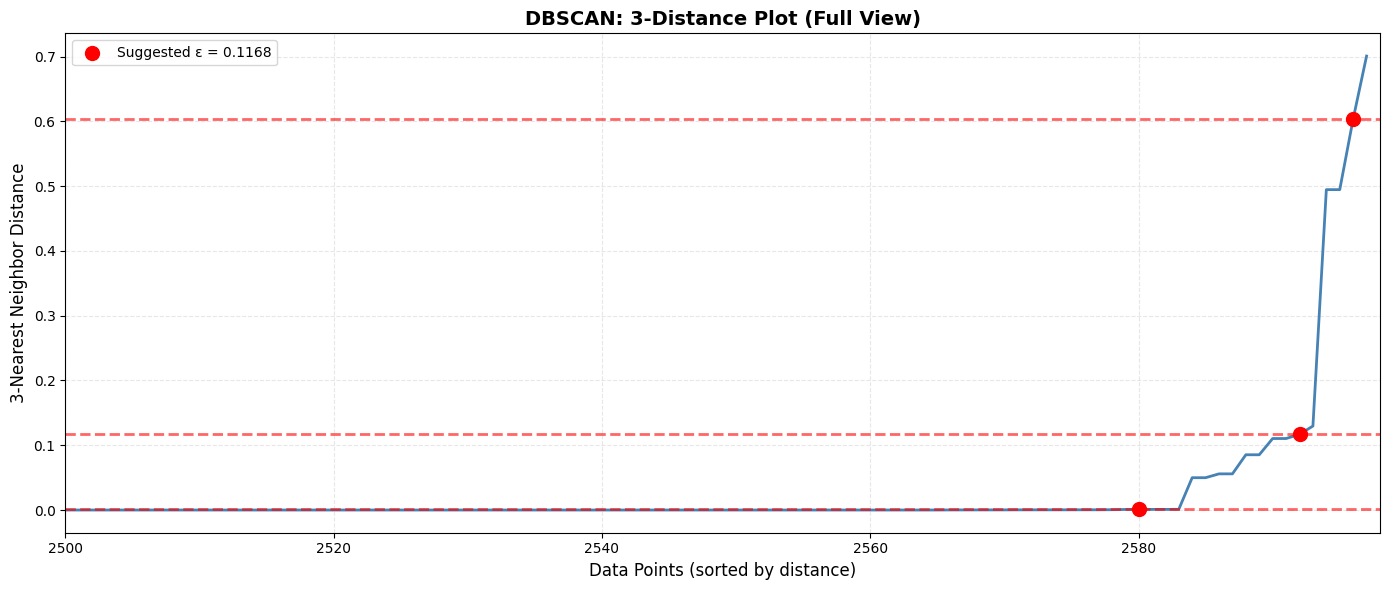


DBSCAN EPSILON FINDER RESULTS
Dataset size: 2598 points
Number of features: 2
K (minPts - 1): 3

Suggested epsilon values:
  1. ε = 0.116806
  2. ε = 0.603906
  3. ε = 0.000974

Testing suggested epsilon values with DBSCAN:
ε = 0.116806
  • Potential core points: 2593 (99.8%)
  • Number of clusters: 33
  • Noise points: 33
ε = 0.603906
  • Potential core points: 2597 (100.0%)
  • Number of clusters: 33
  • Noise points: 32
ε = 0.000974
  • Potential core points: 2583 (99.4%)
  • Number of clusters: 33
  • Noise points: 33


In [ ]:
k = 3  # k = minPts - 1, so minPts = 4 for DBSCAN

# Use NearestNeighbors to efficiently compute distances
coords = np.radians(df[["Latitude", "Longitude"]].dropna().reset_index(drop=True))
nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm="ball_tree", metric="haversine")
nbrs.fit(coords)

# Get distances to k nearest neighbors
distances_matrix, indices = nbrs.kneighbors(coords)

# Extract k-th nearest neighbor distance for each point
k_distances = distances_matrix[:, k]

# Sort distances in ascending order (Step 7 of algorithm)
k_distances_sorted = np.sort(k_distances)


def find_elbow_points(distances, sensitivity=1.5):
    """Find potential elbow points using gradient analysis."""
    n = len(distances)

    # Calculate derivatives
    first_derivative = np.gradient(distances)
    second_derivative = np.gradient(first_derivative)

    # Focus on upper portion where elbows typically appear
    start_idx = int(n * 0.5)
    second_deriv_section = second_derivative[start_idx:]

    if len(second_deriv_section) == 0:
        return []

    # Find local maxima in second derivative
    threshold = np.mean(second_deriv_section) + sensitivity * np.std(second_deriv_section)

    elbow_indices = []
    for i in range(1, len(second_deriv_section) - 1):
        if (second_deriv_section[i] > threshold and
            second_deriv_section[i] > second_deriv_section[i-1] and
            second_deriv_section[i] > second_deriv_section[i+1]):
            elbow_indices.append(start_idx + i)

    # Fallback to percentiles if no clear elbows
    if len(elbow_indices) == 0:
        elbow_indices = [int(n * 0.90), int(n * 0.95)]

    # Return corresponding epsilon values
    elbow_distances = [distances[idx] for idx in elbow_indices]

    # Sort by prominence
    if len([idx for idx in elbow_indices if idx >= start_idx]) > 0:
        prominence = [second_derivative[idx] if idx >= start_idx else 0 for idx in elbow_indices]
        sorted_pairs = sorted(zip(elbow_distances, prominence), key=lambda x: x[1], reverse=True)
        elbow_distances = [dist for dist, _ in sorted_pairs]

    return elbow_distances[:3]  # Top 3 suggestions

# Find suggested epsilon values
suggested_eps = find_elbow_points(k_distances_sorted)

fig, ax1 = plt.subplots(1, figsize=(14, 6))

ax1.plot(k_distances_sorted, linewidth=2, color='steelblue')
ax1.set_xlim(2500, len(k_distances_sorted))
ax1.set_xlabel('Data Points (sorted by distance)', fontsize=12)
ax1.set_ylabel(f'{k}-Nearest Neighbor Distance', fontsize=12)
ax1.set_title(f'DBSCAN: {k}-Distance Plot (Full View)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Mark suggested epsilon values
for eps in suggested_eps:
    idx = np.argmin(np.abs(k_distances_sorted - eps))
    ax1.axhline(y=eps, color='red', linestyle='--', alpha=0.6, linewidth=2)
    ax1.scatter([idx], [eps], color='red', s=100, zorder=5,
               label=f'Suggested ε = {eps:.4f}' if eps == suggested_eps[0] else '')


if suggested_eps:
    ax1.legend(fontsize=10)

plt.tight_layout()
plt.show()

n_samples = coords.shape[0]
print("\n" + "="*70)
print("DBSCAN EPSILON FINDER RESULTS")
print("="*70)
print(f"Dataset size: {n_samples} points")
print(f"Number of features: {coords.shape[1]}")
print(f"K (minPts - 1): {k}")
print(f"\nSuggested epsilon values:")

for i, eps in enumerate(suggested_eps, 1):
    print(f"  {i}. ε = {eps:.6f}")

# Test each suggested epsilon value
print("\nTesting suggested epsilon values with DBSCAN:")

test_results = {}
for eps in suggested_eps:
    # Count potential core points
    core_point_count = np.sum(k_distances_sorted <= eps)
    percentage = (core_point_count / n_samples) * 100

    # Convert eps from kilometers to radians for haversine
    eps_radians = eps / 6371.0

    # Run DBSCAN
    dbscan = DBSCAN(eps=eps_radians, min_samples=k+1, metric="haversine")
    labels = dbscan.fit_predict(coords)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    # # DEBUG: Print cluster size distribution
    # unique, counts = np.unique(labels[labels != -1], return_counts=True)
    # print(f"DEBUG: Cluster sizes - min: {counts.min()}, max: {counts.max()}, mean: {counts.mean():.1f}")

    test_results[eps] = {
        'labels': labels,
        'n_clusters': n_clusters,
        'n_noise': n_noise
    }

    print(f"ε = {eps:.6f}")
    print(f"  • Potential core points: {core_point_count} ({percentage:.1f}%)")
    print(f"  • Number of clusters: {n_clusters}")
    print(f"  • Noise points: {n_noise}")

In [ ]:
dbscaneps = 0.116806/6371 #6371 is the mean radius of the Earth in kilometers

# Perform DBSCAN clustering on raw coordinates using Haversine metric

# DBSCAN is a density-based clustering algorithm
dbscan = DBSCAN(eps=dbscaneps, min_samples=5, metric="haversine")
dbscan_labels = dbscan.fit_predict(coords)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN Results:")
print(f"  Clusters found: {n_clusters_dbscan}")
print(f"  Noise points: {n_noise}")

# Create result dataframe with clustering results

result_df = (df[['Longitude', 'Latitude']].copy()
            .dropna()
            .reset_index(drop=True)
)
result_df['Cluster_DBSCAN'] = dbscan_labels

result_df = result_df.drop_duplicates()

# Adding clusters to dataframe

df = (df.merge(result_df, how="left", on=["Longitude", "Latitude"])
        .drop(columns=["IP Address", "Longitude", "Latitude", "Country", "City", "State/Region", "Postal", "User Agent"])
)
df.rename(columns={"Cluster_DBSCAN": "Position_Cluster_ID"}, inplace=True)

DBSCAN Results:
  Clusters found: 31
  Noise points: 41


In [ ]:
map_df = result_df.copy()

# Initialize the map centered at the average location
center_lat = map_df['Latitude'].mean()
center_lon = map_df['Longitude'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=2, tiles='CartoDB positron')

# Define a color palette for clusters
cmap = plt.cm.get_cmap('tab20', n_clusters)
colors = [mcolors.rgb2hex(cmap(i)) for i in range(n_clusters)]

# Create a feature group for each cluster to allow toggling
cluster_groups = {}

for cluster in sorted(map_df['Cluster_DBSCAN'].unique()):
    color = colors[int(cluster) % len(colors)] if cluster != -1 else 'black'
    group_name = f'Cluster {cluster}' if cluster != -1 else 'Noise'

    group = folium.FeatureGroup(name=group_name)

    cluster_pts = map_df[map_df['Cluster_DBSCAN'] == cluster]

    for _, row in cluster_pts.iterrows():
        popup_text = f"Cluster: {cluster}<br>Nationality: {row.get('Please indicate your nationality.', 'N/A')}"

        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=5,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=folium.Popup(popup_text, max_width=300),

            tooltip=group_name
        ).add_to(group)

    group.add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Display the map
m


In [ ]:
# One-hot encoding
df = pd.get_dummies(df, columns=['Which of these factors would most motivate you to apply for a position at the organisation?'], dtype=int
)

# Display basic cleaned dataset
print(df.shape)
df.head()

(2614, 26)


,Response ID,Time Started,Date Submitted,Status,Which higher education institution do you or did you study at?,Which of the following best describes the main subject that you are studying?,Please indicate your nationality.,What is your gender?,Which of these statements best describes your current perception of the organisation as an employer?,"On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?",...,Education_level,Position_Cluster_ID,Which of these factors would most motivate you to apply for a position at the organisation?_Career growth opportunities,Which of these factors would most motivate you to apply for a position at the organisation?_Compensation package,Which of these factors would most motivate you to apply for a position at the organisation?_Job security,Which of these factors would most motivate you to apply for a position at the organisation?_Learning and development,Which of these factors would most motivate you to apply for a position at the organisation?_Meaningful work impact,Which of these factors would most motivate you to apply for a position at the organisation?_Others,Which of these factors would most motivate you to apply for a position at the organisation?_Unknown,Which of these factors would most motivate you to apply for a position at the organisation?_Work-life balance
0,19,2025-09-02 15:03:01,2025-09-02 15:03:40,Partial,National University of Singapore (NUS),"Business/Management (Accounting, Finance, Marketing, Management, etc.)",Singaporean/Singapore PR,Female,Unknown,0.555556,...,0.40,0.0,0,0,0,0,0,0,1,0
1,20,2025-09-02 15:15:32,2025-09-02 15:16:59,Disqualified,Singapore Management University (SMU),Economics,Singaporean/Singapore PR,Female,Unknown,0.555556,...,0.35,-1.0,0,0,0,0,0,0,1,0
2,21,2025-09-02 15:18:01,2025-09-02 15:19:30,Disqualified,Singapore Management University (SMU),Economics,"Non-Singaporean, with long-term residence status",Female,Unknown,0.555556,...,0.35,-1.0,0,0,0,0,0,0,1,0
3,22,2025-09-03 15:25:18,2025-09-03 15:27:05,Complete,Nanyang Technological University (NTU),Economics,Singaporean/Singapore PR,Female,I’m familiar with the organisation and would consider them as a potential employer,0.777778,...,0.40,1.0,0,0,0,0,1,0,0,0
4,23,2025-09-03 15:34:31,2025-09-03 15:34:31,Partial,Others,NaN,Singaporean/Singapore PR,Prefer not to say,Unknown,0.555556,...,0.25,-1.0,0,0,0,0,0,0,1,0


### **Identify patterns, and redundancies in survey questions for improvement**

In [ ]:
df_1 = df.copy()
df_1 = pd.get_dummies(df, columns=[
                                 'Which of the following best describes the main subject that you are studying?',
                                 'Which of these statements best describes your current perception of the organisation as an employer?',
                                 'Please indicate your nationality.',
                                 'Which higher education institution do you or did you study at?',
                                 'What is your gender?'], dtype=int)
df_1 = df_1[df_1["Status"] == "Complete"]
df_1.drop(columns=["Response ID", "Time Started", "Date Submitted", "Status", "Position_Cluster_ID"], inplace=True)
df_1.rename(columns={'On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?' :
                     'How would you rate the attractiveness of the organisation as an employer?'}, inplace=True)
df_1.head()

,How would you rate the attractiveness of the organisation as an employer?,What do you wish to learn more about regarding the organisation as an employer?_Types of roles available,What do you wish to learn more about regarding the organisation as an employer?_Career progression and development,What do you wish to learn more about regarding the organisation as an employer?_Compensation and benefits,What do you wish to learn more about regarding the organisation as an employer?_Work-life balance and culture,What do you wish to learn more about regarding the organisation as an employer?_Application and interview process,What do you wish to learn more about regarding the organisation as an employer?_Others,Education_level,Which of these factors would most motivate you to apply for a position at the organisation?_Career growth opportunities,Which of these factors would most motivate you to apply for a position at the organisation?_Compensation package,...,Which higher education institution do you or did you study at?_SIM Global Education,Which higher education institution do you or did you study at?_Singapore Institute of Technology (SIT),Which higher education institution do you or did you study at?_Singapore Management University (SMU),Which higher education institution do you or did you study at?_Singapore University of Social Sciences (SUSS),Which higher education institution do you or did you study at?_Singapore University of Technology and Design (SUTD),Which higher education institution do you or did you study at?_University of Nevada Las Vegas Singapore (UNLV),Which higher education institution do you or did you study at?_Yale-NUS College,What is your gender?_Female,What is your gender?_Male,What is your gender?_Prefer not to say
3,0.777778,1,1,0,0,1,0,0.40,0,0,...,0,0,0,0,0,0,0,1,0,0
9,0.555556,0,1,1,1,0,0,0.35,0,0,...,0,0,0,0,0,0,0,1,0,0
13,0.666667,0,1,1,1,0,0,0.35,1,0,...,0,0,0,0,0,0,0,1,0,0
16,0.444444,0,1,1,1,0,0,0.30,0,0,...,0,0,0,0,0,0,0,1,0,0
17,0.777778,1,1,1,0,0,0,0.30,0,0,...,0,0,1,0,0,0,0,1,0,0


In [ ]:
survey_qns = ['What do you wish to learn more about regarding the organisation as an employer?',
              'Which of these factors would most motivate you to apply for a position at the organisation?',
              'Which of the following best describes the main subject that you are studying?',
              'Which of these statements best describes your current perception of the organisation as an employer?',
              'Please indicate your nationality.',
              'Which higher education institution do you or did you study at?',
              'What is your gender?']
numeric_cols = ['Education_level', 'How would you rate the attractiveness of the organisation as an employer?']
# Set a threshold for "Rare" categories (1% of total respondents)
threshold = len(df_1) * 0.01

#### **Global MCA**

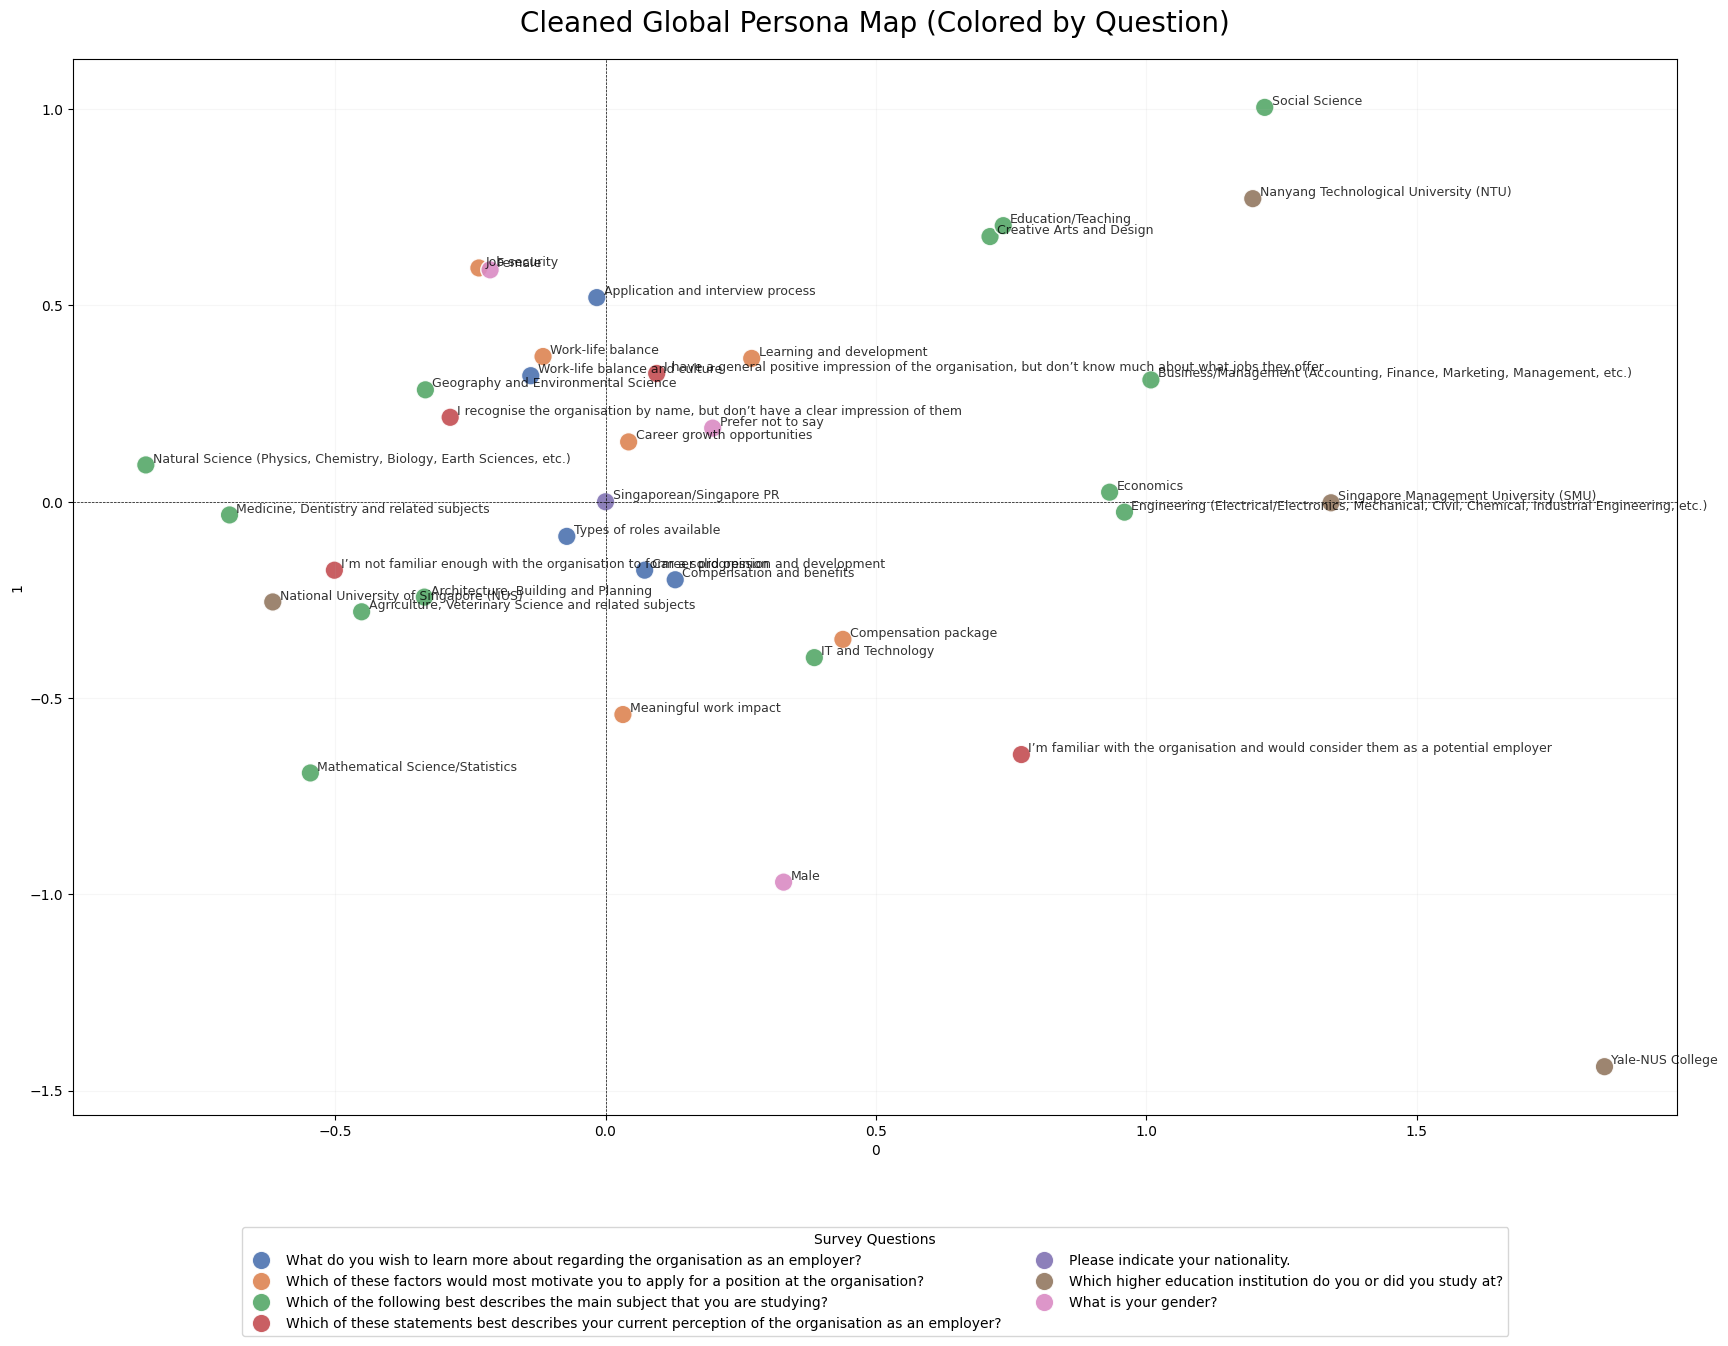


Top 10 contributing categories to Component  (After Filtering):0

National University of Singapore (NUS)__No                                                 0.179693
Nanyang Technological University (NTU)__Yes                                                0.130078
National University of Singapore (NUS)__Yes                                                0.097265
Natural Science (Physics, Chemistry, Biology, Earth Sciences, etc.)__Yes                   0.077393
Business/Management (Accounting, Finance, Marketing, Management, etc.)__Yes                0.051404
I’m familiar with the organisation and would consider them as a potential employer__Yes    0.047361
Nanyang Technological University (NTU)__No                                                 0.038731
Yale-NUS College__Yes                                                                      0.031426
Name: 0, dtype: float64


Least contributing categories to Component  (After Filtering):0

Singaporean/Singapore PR__Yes             

In [ ]:
df_mca_input = pd.DataFrame()

# Process all questions with PRE-FILTERING
for qns in survey_qns:
    cols = [c for c in df_1.columns if c.startswith(qns)]
    if not cols: continue

    temp_d = df_1[cols].copy()
    temp_d.columns = [c.split('_')[-1].strip() if '_' in c else c for c in cols]

    # --- FILTERING START ---
    # 1. Drop any column explicitly named "Others" or "Other"
    to_drop = [c for c in temp_d.columns if 'other' in c.lower()]

    # 2. Identify "Rare" categories (Low 'Yes' frequency)
    yes_counts = (temp_d == 1).sum()
    rare_cols = yes_counts[yes_counts < threshold].index.tolist()

    # Combine and drop from this question's subset
    final_drops = list(set(to_drop + rare_cols))
    temp_d = temp_d.drop(columns=final_drops)
    # --- FILTERING END ---

    # Map to Yes/No for MCA
    for c in temp_d.columns:
        temp_d[c] = temp_d[c].map({0: "No", 1: "Yes"}).astype("category")

    df_mca_input = pd.concat([df_mca_input, temp_d], axis=1)

# 3. Fit the Global MCA
mca = prince.MCA(
    n_components=5,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mca = mca.fit(df_mca_input)

# 4. Extract Coordinates (Filtering "Yes" for the plot)
coords = mca.column_coordinates(df_mca_input)
coords_yes = coords[coords.index.str.contains("Yes")].copy()

# Create question-answer map
feature_to_qns = {}
for qns in survey_qns:
    q_cols = [c.split('_')[1].strip() for c in df_1.columns if c.startswith(qns)]
    for col in q_cols:
        feature_to_qns[col + "__Yes"] = qns

# 5. Prepare plotting data
z_scores = np.abs((coords_yes - coords_yes.mean()) / coords_yes.std())
filtered_mask = (z_scores < 3).all(axis=1)
filtered_coords = coords_yes[filtered_mask]

plot_labels = [feature_to_qns.get(idx, "Other") for idx in filtered_coords.index]
clean_index = [i.split('__')[0].replace("_Yes", "").strip() for i in filtered_coords.index]

# 6. Plot
palette = sns.color_palette("hls", len(survey_qns))

plt.figure(figsize=(18, 14))
sns.scatterplot(
    x=filtered_coords[0],
    y=filtered_coords[1],
    hue=plot_labels,
    s=180,
    alpha=0.9,
    edgecolor='w',
    palette="deep"
)

plt.legend(
    title="Survey Questions",
    bbox_to_anchor=(0.5, -0.1),
    loc='upper center',
    ncol=2,
    fontsize=10,
    frameon=True
)

for i, txt in enumerate(clean_index):
    plt.annotate(txt, (filtered_coords.iloc[i, 0], filtered_coords.iloc[i, 1]),
                 fontsize=9, alpha=0.8, xytext=(5, 2), textcoords='offset points')

plt.axhline(0, color='black', ls='--', lw=0.5)
plt.axvline(0, color='black', ls='--', lw=0.5)
plt.title("Cleaned Global Persona Map (Colored by Question)", fontsize=20, pad=20)
# plt.legend(title="Survey Questions", bbox_to_anchor=(1.05, 1), loc='upper left') # 图例放外面
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

# 6. Contributions
print("\nTop 10 contributing categories to Component  (After Filtering):0\n")
print(mca.column_contributions_.iloc[:, 0].sort_values(ascending=False).head(8))

print("\n\nLeast contributing categories to Component  (After Filtering):0\n")
print(mca.column_contributions_.iloc[:, 0].sort_values(ascending=True).head(8))

#### **Independent MCA**

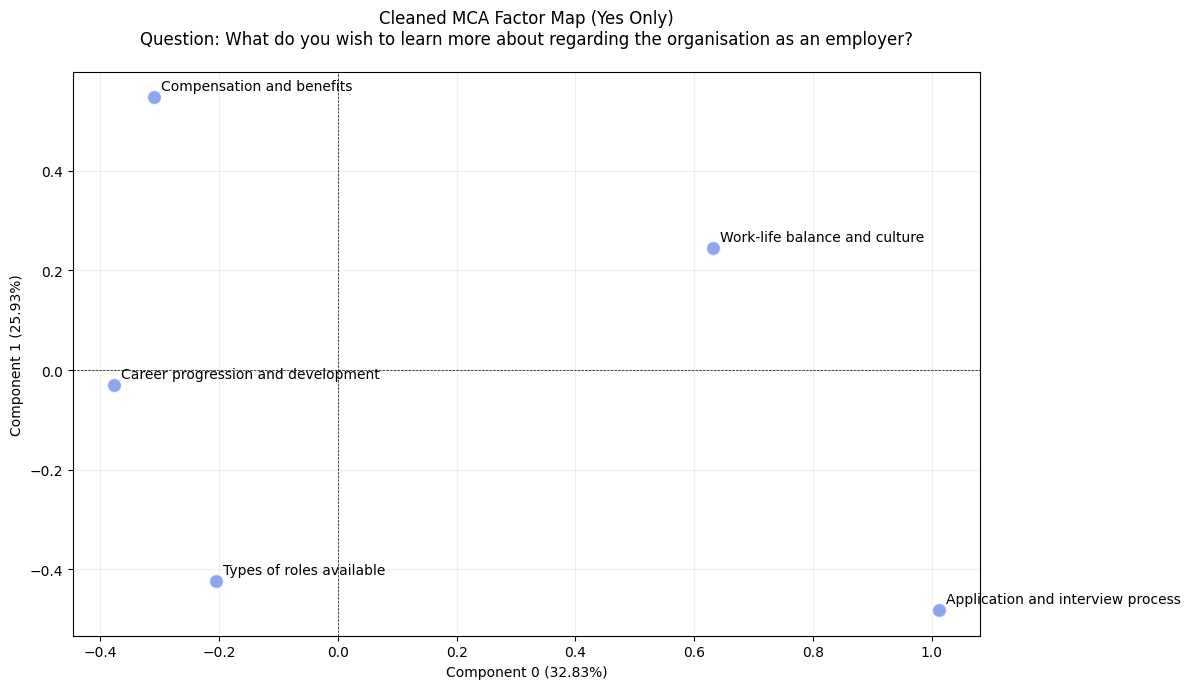


--- Category Tendency Analysis (Similarity Scores): What do you wish to learn more about regarding the ---
                                    Similarity_Dim0  Similarity_Dim1
Work-life balance and culture              0.697352         0.270882
Application and interview process          0.645602        -0.306985
Types of roles available                  -0.369302        -0.764179
Compensation and benefits                 -0.417323         0.736311
Career progression and development        -0.654164        -0.052520


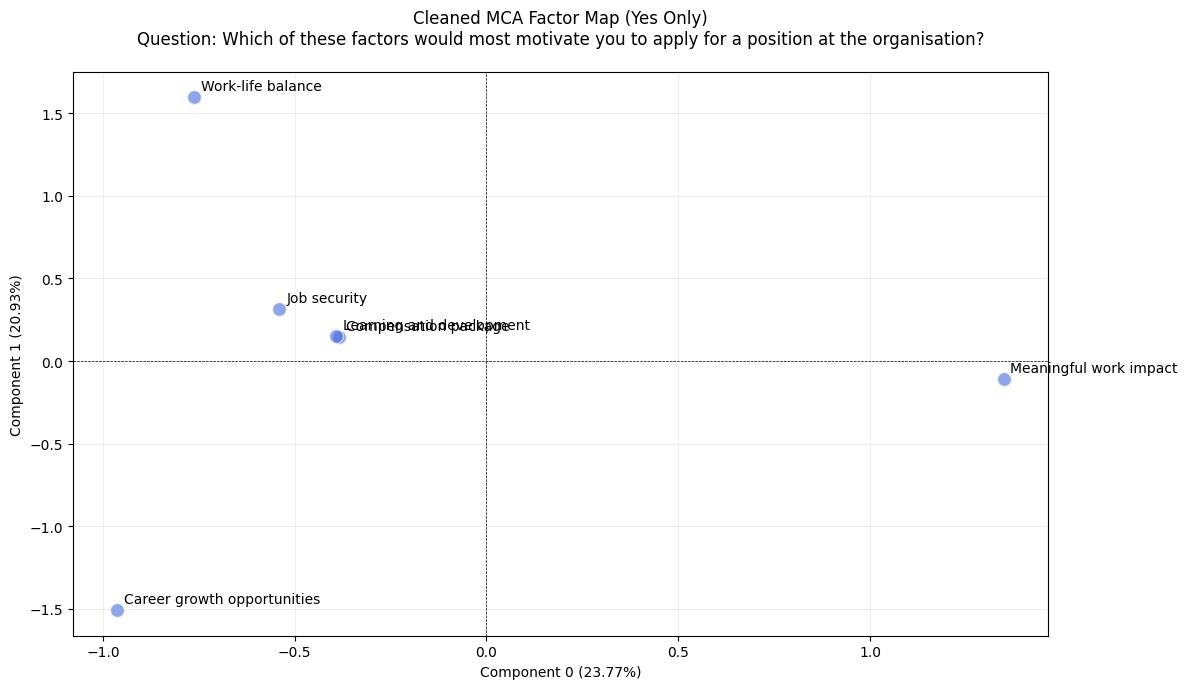


--- Category Tendency Analysis (Similarity Scores): Which of these factors would most motivate you to  ---
                             Similarity_Dim0  Similarity_Dim1
Meaningful work impact              0.985436        -0.080234
Compensation package               -0.086534         0.033364
Learning and development           -0.094961         0.037270
Job security                       -0.215077         0.124615
Work-life balance                  -0.371604         0.777603
Career growth opportunities        -0.506272        -0.792590


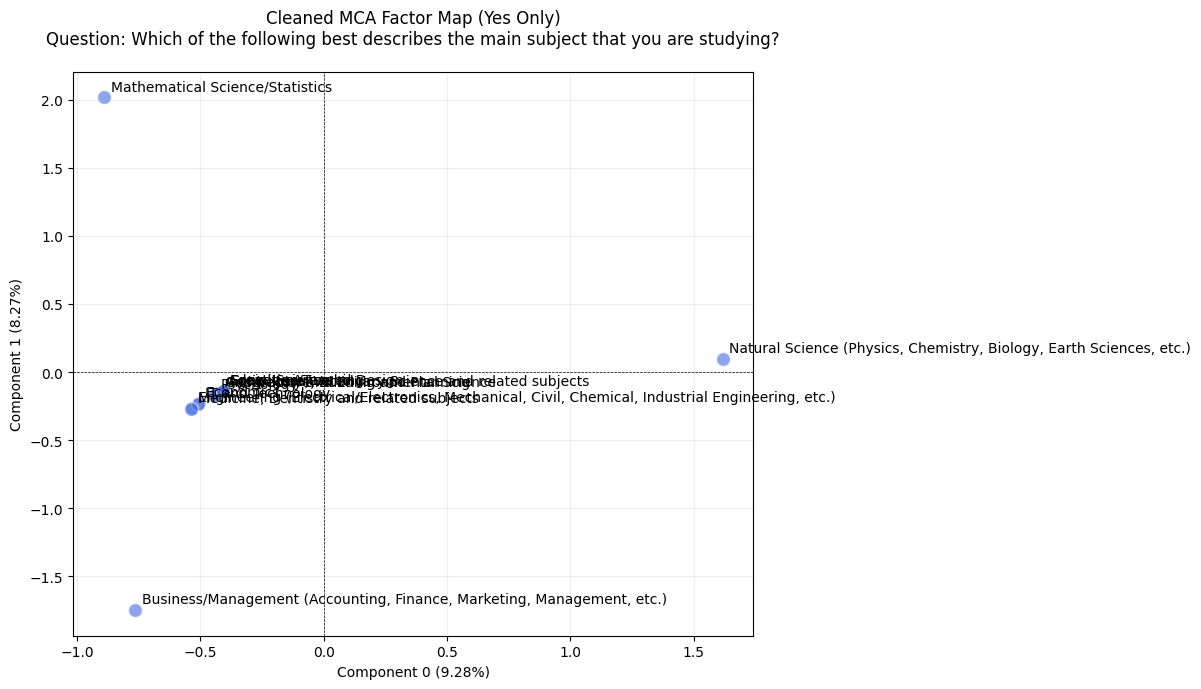


--- Category Tendency Analysis (Similarity Scores): Which of the following best describes the main sub ---
                                                                                                 Similarity_Dim0  \
Natural Science (Physics, Chemistry, Biology, Earth Sciences, etc.)                                     0.990758   
Engineering (Electrical/Electronics, Mechanical, Civil, Chemical, Industrial Engineering, etc.)        -0.156583   
Medicine, Dentistry and related subjects                                                               -0.158525   
IT and Technology                                                                                      -0.191436   
Economics                                                                                              -0.243991   
Business/Management (Accounting, Finance, Marketing, Management, etc.)                                 -0.294841   
Mathematical Science/Statistics                                                 

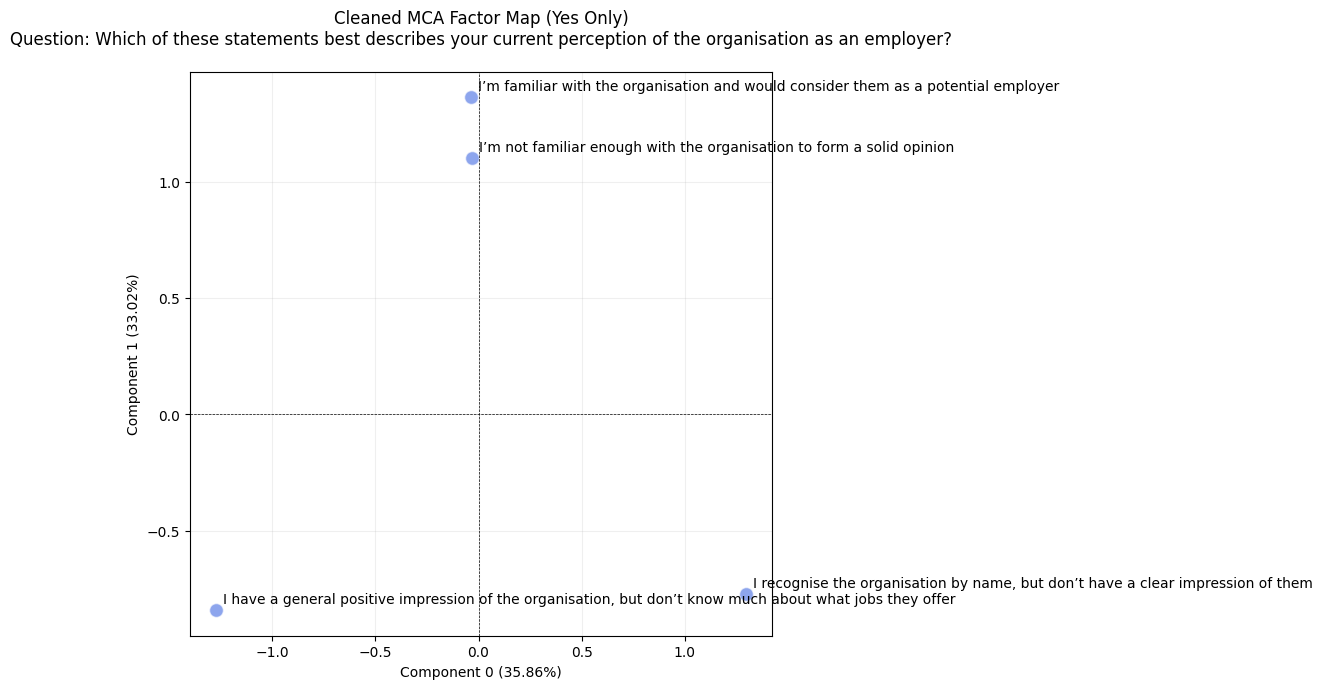


--- Category Tendency Analysis (Similarity Scores): Which of these statements best describes your curr ---
                                                                                                          Similarity_Dim0  \
I recognise the organisation by name, but don’t have a clear impression of them                                  0.755176   
I’m not familiar enough with the organisation to form a solid opinion                                           -0.014826   
I’m familiar with the organisation and would consider them as a potential employer                              -0.016592   
I have a general positive impression of the organisation, but don’t know much about what jobs they offer        -0.734647   

                                                                                                          Similarity_Dim1  
I recognise the organisation by name, but don’t have a clear impression of them                                 -0.447825  
I’m not familiar e

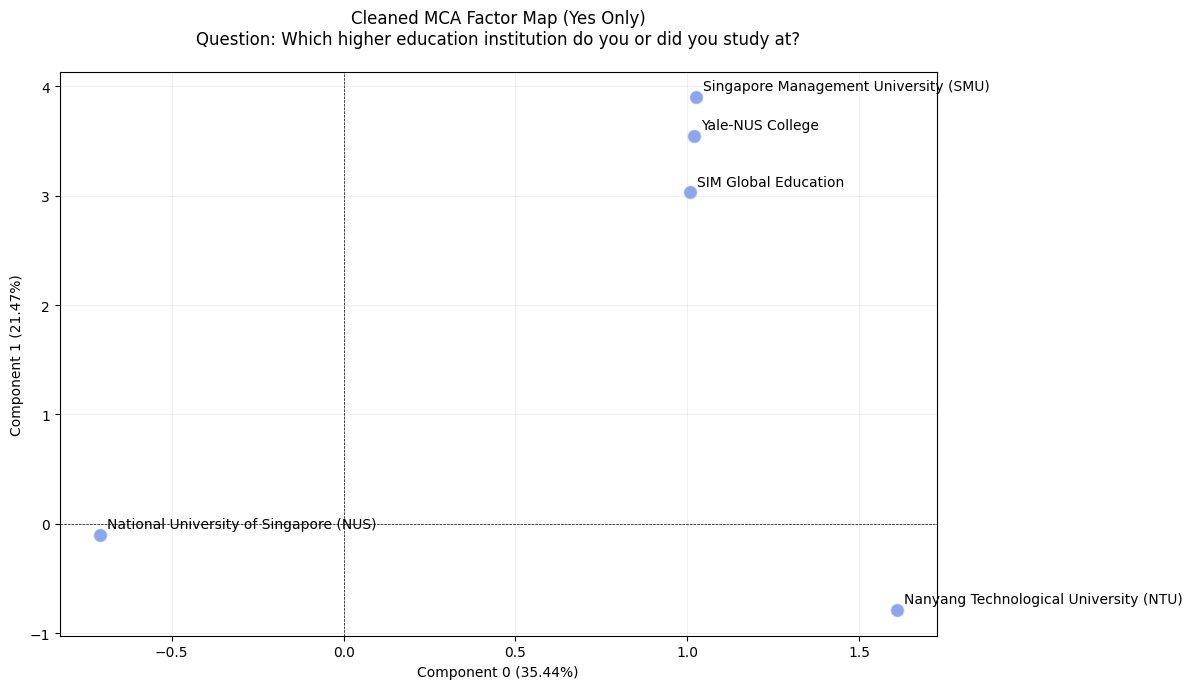


--- Category Tendency Analysis (Similarity Scores): Which higher education institution do you or did y ---
                                        Similarity_Dim0  Similarity_Dim1
Nanyang Technological University (NTU)         0.878038        -0.429308
Singapore Management University (SMU)          0.172897         0.656687
Yale-NUS College                               0.157442         0.546578
SIM Global Education                           0.125112         0.375593
National University of Singapore (NUS)        -0.964796        -0.135121


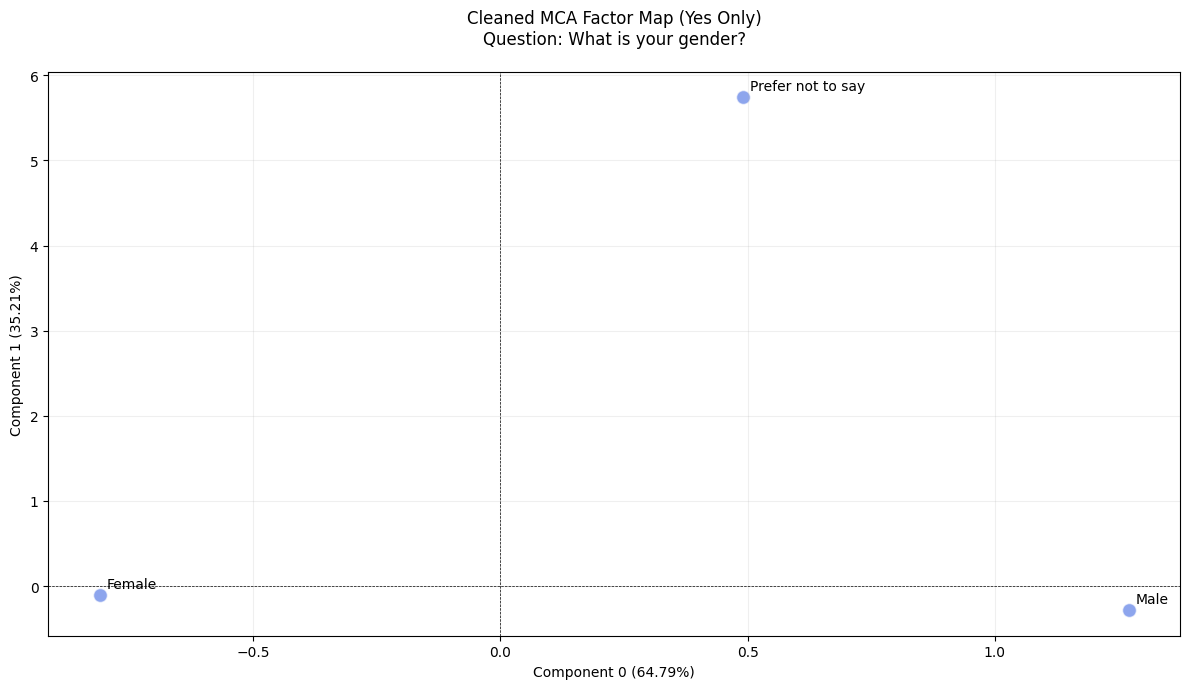


--- Category Tendency Analysis (Similarity Scores): What is your gender? ---
                   Similarity_Dim0  Similarity_Dim1
Male                      0.775179        -0.172560
Prefer not to say         0.083985         0.981812
Female                   -0.629098        -0.081345


In [ ]:
all_row_coords_indi_mca = []

for qns in survey_qns:
    col = [c for c in df_1.columns if c.startswith(qns)]
    if len(col) == 0: continue

    # 1. Prepare sub-dataframe
    col_split = [c.split('_')[1].strip() for c in col]
    d = df_1[col].copy()
    d.columns = col_split

    # Identify columns to keep: not rare AND not an outlier
    yes_counts = (d == 1).sum()
    cols_to_keep = [c for c in d.columns if yes_counts[c] >= threshold and 'Others' not in c]

    if len(cols_to_keep) < 2:
        print(f"Skipping {qns}: Not enough frequent categories after filtering.")
        continue

    d = d[cols_to_keep]
    for c in d.columns:
        d[c] = d[c].map({0: "No", 1: "Yes"}).astype("category")

    mca = prince.MCA(
            n_components=5,
            n_iter=3,
            engine='sklearn',
            random_state=42
    )
    mca = mca.fit(d)

    coords = mca.column_coordinates(d)
    coords_yes = coords[coords.index.str.contains("__Yes")].copy()
    coords_yes.index = [idx.replace("__Yes", "") for idx in coords_yes.index]

    summary = mca.eigenvalues_summary

    # 4. Plotting
    plt.figure(figsize=(12, 7))
    plt.scatter(coords_yes[0], coords_yes[1], c='royalblue', s=100, alpha=0.6, edgecolors='white')

    for i, txt in enumerate(coords_yes.index):
        plt.annotate(txt, (coords_yes.iloc[i, 0], coords_yes.iloc[i, 1]),
                     fontsize=10, xytext=(5, 5), textcoords='offset points')

    plt.axhline(0, color='black', ls='--', lw=0.5)
    plt.axvline(0, color='black', ls='--', lw=0.5)

    var_0, var_1 = summary.iloc[0, 1], summary.iloc[1, 1]

    plt.title(f"Cleaned MCA Factor Map (Yes Only)\nQuestion: {qns}", fontsize=12, pad=20)
    plt.xlabel(f"Component 0 ({var_0})")
    plt.ylabel(f"Component 1 ({var_1})")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    # print(f"\n--- Cleaned Coordinates for: {qns} ---")
    # print(coords_yes)

    # --- 5. Calculate Similarity Scores (Cosine Similarity) ---
    dist_to_origin = np.sqrt((coords_yes**2).sum(axis=1))
    similarity_scores = coords_yes.divide(dist_to_origin, axis=0)
    similarity_scores.columns = [f"Similarity_Dim{i}" for i in range(similarity_scores.shape[1])]

    print(f"\n--- Category Tendency Analysis (Similarity Scores): {qns[:50]} ---")
    display_scores = similarity_scores[['Similarity_Dim0', 'Similarity_Dim1']].copy()
    print(display_scores.sort_values(by='Similarity_Dim0', ascending=False).head(10))

    all_row_coords_indi_mca.append(similarity_scores)

#### **Combined MCA**

Running local MCA feature extraction...
Skipping question: Please indicate your nationali... (not enough valid options)
Cumulative explained variance (global SVD): 46.90%


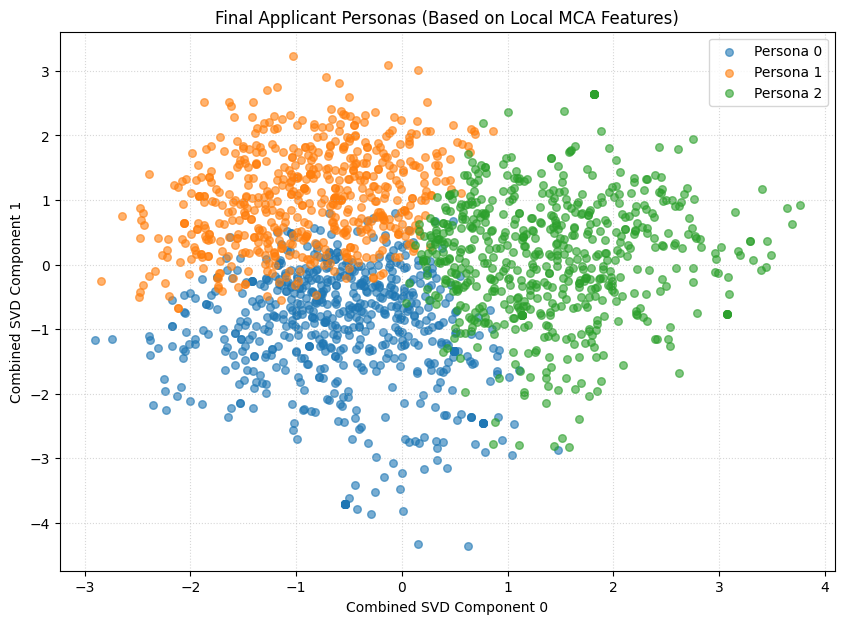


--- Top contributing feature dimensions (absolute loadings) ---
Which_higher_education_institution_do_you_or_did_you_study_at?_Dim0                                          0.598241
Education_level                                                                                              0.372575
Which_of_the_following_best_describes_the_main_subject_that_you_are_studying?_Dim1                           0.372142
Which_of_the_following_best_describes_the_main_subject_that_you_are_studying?_Dim0                           0.321788
Which_of_these_factors_would_most_motivate_you_to_apply_for_a_position_at_the_organisation?_Dim0             0.269202
How would you rate the attractiveness of the organisation as an employer?                                    0.248286
What_do_you_wish_to_learn_more_about_regarding_the_organisation_as_an_employer?_Dim0                         0.200180
Which_of_these_statements_best_describes_your_current_perception_of_the_organisation_as_an_employer?_Dim0    

In [ ]:
# --- Configuration ---
n_mca_components = 2               # Number of MCA dimensions per question (usually 2–3 for interpretability)
n_final_svd_components = 5         # Number of global dimensions kept after final SVD
n_clusters = 3                     # Number of personas/clusters desired
all_row_coords = []

# --- Stage 1: Local MCA feature extraction per question ---
print("Running local MCA feature extraction...")
for qns in survey_qns:
    col = [c for c in df_1.columns if c.startswith(qns)]
    if len(col) == 0:
        continue

    # 1) Build a subset for this question and clean column names
    d = df_1[col].copy()
    d.columns = [c.split('_')[1].strip() if '_' in c else c for c in col]

    # 2) Filter sparse options and exclude "Others"
    yes_counts = (d == 1).sum()
    cols_to_keep = [c for c in d.columns if yes_counts[c] >= threshold and 'Others' not in c]

    if len(cols_to_keep) < 2:
        print(f"Skipping question: {qns[:30]}... (not enough valid options)")
        continue

    d = d[cols_to_keep]

    # 3) Convert 0/1 to categorical labels required by prince.MCA
    for c in d.columns:
        d[c] = d[c].map({0: "No", 1: "Yes"}).astype("category")

    # 4) Fit local MCA
    mca = prince.MCA(n_components=n_mca_components, n_iter=3, random_state=42)
    mca = mca.fit(d)

    # 5) Extract row coordinates as features for this question
    row_coords = mca.row_coordinates(d)

    # Rename columns, e.g., "QuestionName_Dim0", "QuestionName_Dim1"
    short_name = qns.replace(" ", "_")
    row_coords.columns = [f"{short_name}_Dim{i}" for i in range(row_coords.shape[1])]

    all_row_coords.append(row_coords)

# --- Stage 2: Feature concatenation + standardization ---
# Concatenate all local MCA coordinates into a single feature table
X_mca = pd.concat(all_row_coords, axis=1)

# Add numeric features (keep the same rows/index)
X_numeric = df_1[
    ['Education_level',
     'How would you rate the attractiveness of the organisation as an employer?']
]

X_combined = pd.concat([X_mca, X_numeric], axis=1)

# Standardize so features from different questions are on comparable scales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# --- Stage 3: Global SVD dimensionality reduction ---
# Each column in X_scaled still has a clear provenance (question-level MCA dimension or numeric feature)
svd = TruncatedSVD(n_components=n_final_svd_components, random_state=42)
coords_final = svd.fit_transform(X_scaled)

# Print cumulative explained variance to validate reduction quality
cum_variance = np.sum(svd.explained_variance_ratio_)
print(f"Cumulative explained variance (global SVD): {cum_variance:.2%}")

# --- Stage 4: Final clustering (KMeans) ---
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(coords_final)

# Write cluster labels back to the original dataframe
df_1['final_cluster'] = clusters

# --- Stage 5: Visualization (2D projection using first two SVD components) ---
plt.figure(figsize=(10, 7))
for k in range(n_clusters):
    d_plot = coords_final[clusters == k]
    plt.scatter(d_plot[:, 0], d_plot[:, 1], s=30, alpha=0.6, label=f"Persona {k}")

plt.xlabel("Combined SVD Component 0")
plt.ylabel("Combined SVD Component 1")
plt.title("Final Applicant Personas (Based on Local MCA Features)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# --- Stage 6: Interpretability backtracking ---
# Inspect which original feature dimensions contribute most to the SVD components
print("\n--- Top contributing feature dimensions (absolute loadings) ---")
loadings = pd.DataFrame(
    svd.components_.T,
    index=X_combined.columns,
    columns=[f"SVD_Comp_{i}" for i in range(n_final_svd_components)]
)

print(loadings.abs().sort_values(by="SVD_Comp_0", ascending=False)['SVD_Comp_0'].head(10))

In [ ]:
# Derive question importance
question_impact = loadings.abs().groupby(lambda x: x.split('_Dim')[0]).mean()

print("\n==== Survey Opportunity Audit (Contribution Score) ====")
# Highest scores: Core differentiators | Lowest scores: Redundant/Low-value questions
print(question_impact['SVD_Comp_0'].sort_values(ascending=False))


==== Survey Opportunity Audit (Contribution Score) ====
Education_level                                                                                         0.372575
Which_of_the_following_best_describes_the_main_subject_that_you_are_studying?                           0.346965
Which_higher_education_institution_do_you_or_did_you_study_at?                                          0.339785
How would you rate the attractiveness of the organisation as an employer?                               0.248286
Which_of_these_factors_would_most_motivate_you_to_apply_for_a_position_at_the_organisation?             0.163928
Which_of_these_statements_best_describes_your_current_perception_of_the_organisation_as_an_employer?    0.156803
What_do_you_wish_to_learn_more_about_regarding_the_organisation_as_an_employer?                         0.113917
What_is_your_gender?                                                                                    0.112334
Name: SVD_Comp_0, dtype: float64


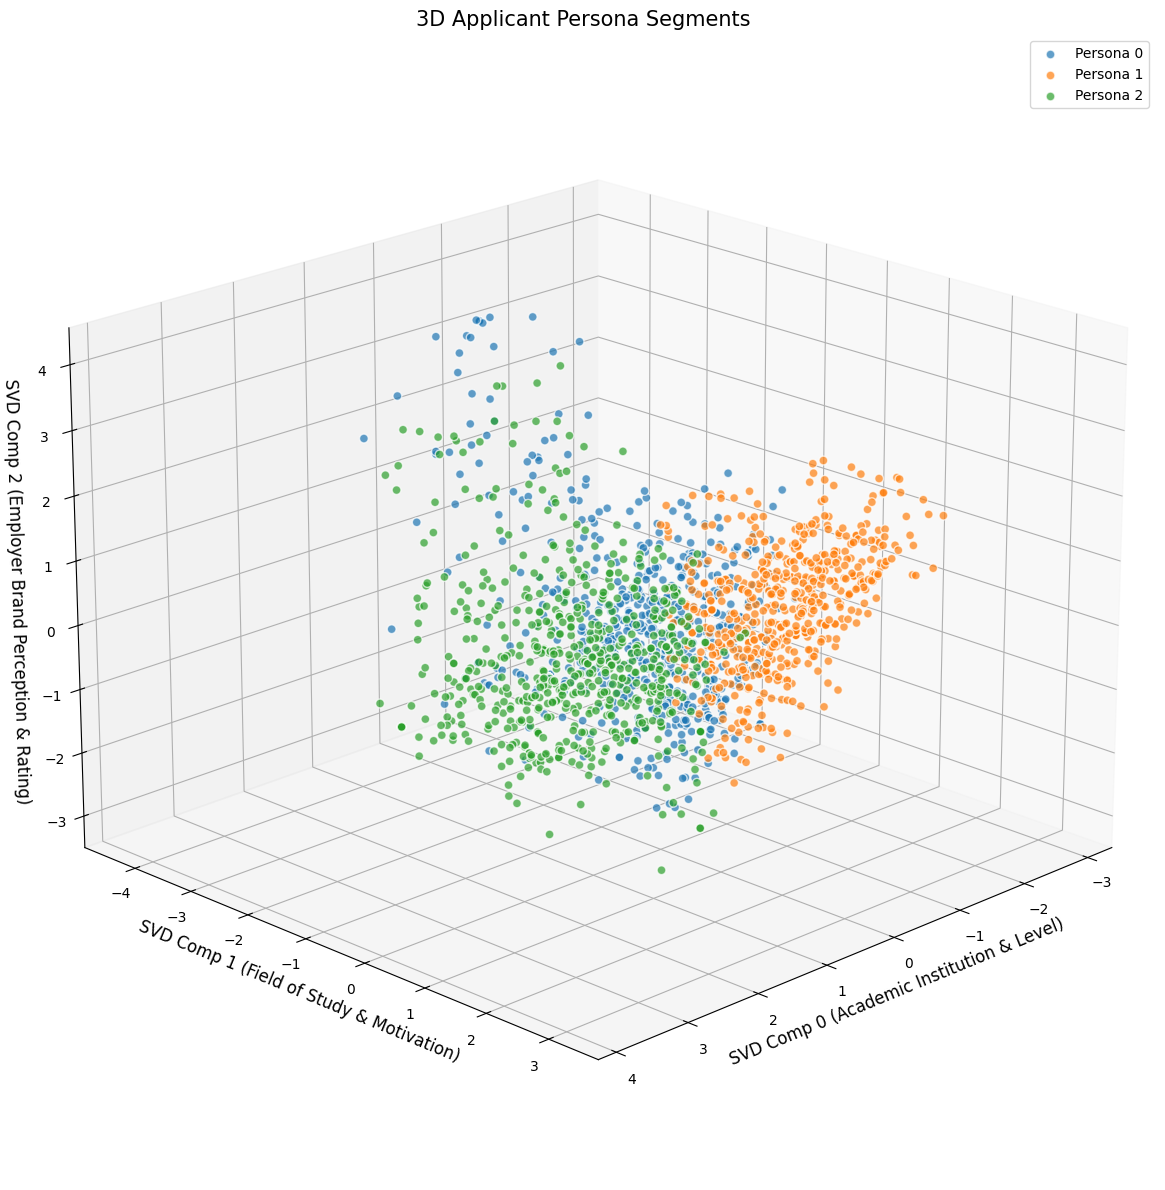

In [ ]:
# --- Stage 7 Extension: 3D Visualization ---
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# Define custom color palette for Personas
# blue: Persona 0, orange: Persona 1, green: Persona 2
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for k in range(n_clusters):
    d_plot = coords_final[clusters == k]
    ax.scatter(d_plot[:, 0], d_plot[:, 1], d_plot[:, 2],
               s=40, alpha=0.7, label=f"Persona {k}", edgecolors='w')

# Set Axis Labels
ax.set_xlabel('SVD Comp 0 (Academic Institution & Level)', fontsize=12)
ax.set_ylabel('SVD Comp 1 (Field of Study & Motivation)', fontsize=12)
ax.set_zlabel('SVD Comp 2 (Employer Brand Perception & Rating)', fontsize=12)

ax.set_title("3D Applicant Persona Segments", fontsize=15)
ax.legend()

# Set initial camera angle
# elev: elevation angle, azim: azimuthal angle (rotation)
# You can adjust these values to find the best separation between clusters
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()


==== Numeric Feature Comparison (Mean Value Analysis) ====

Feature: Education_level
  Cluster 0: 0.31 (↑ Deviation from Total: 0.00)
  Cluster 1: 0.33 (↑ Deviation from Total: 0.02)
  Cluster 2: 0.28 (↓ Deviation from Total: -0.02)

Feature: How would you rate the attractiveness of the organisation as an employer?
  Cluster 0: 0.62 (↑ Deviation from Total: 0.03)
  Cluster 1: 0.49 (↓ Deviation from Total: -0.09)
  Cluster 2: 0.64 (↑ Deviation from Total: 0.06)


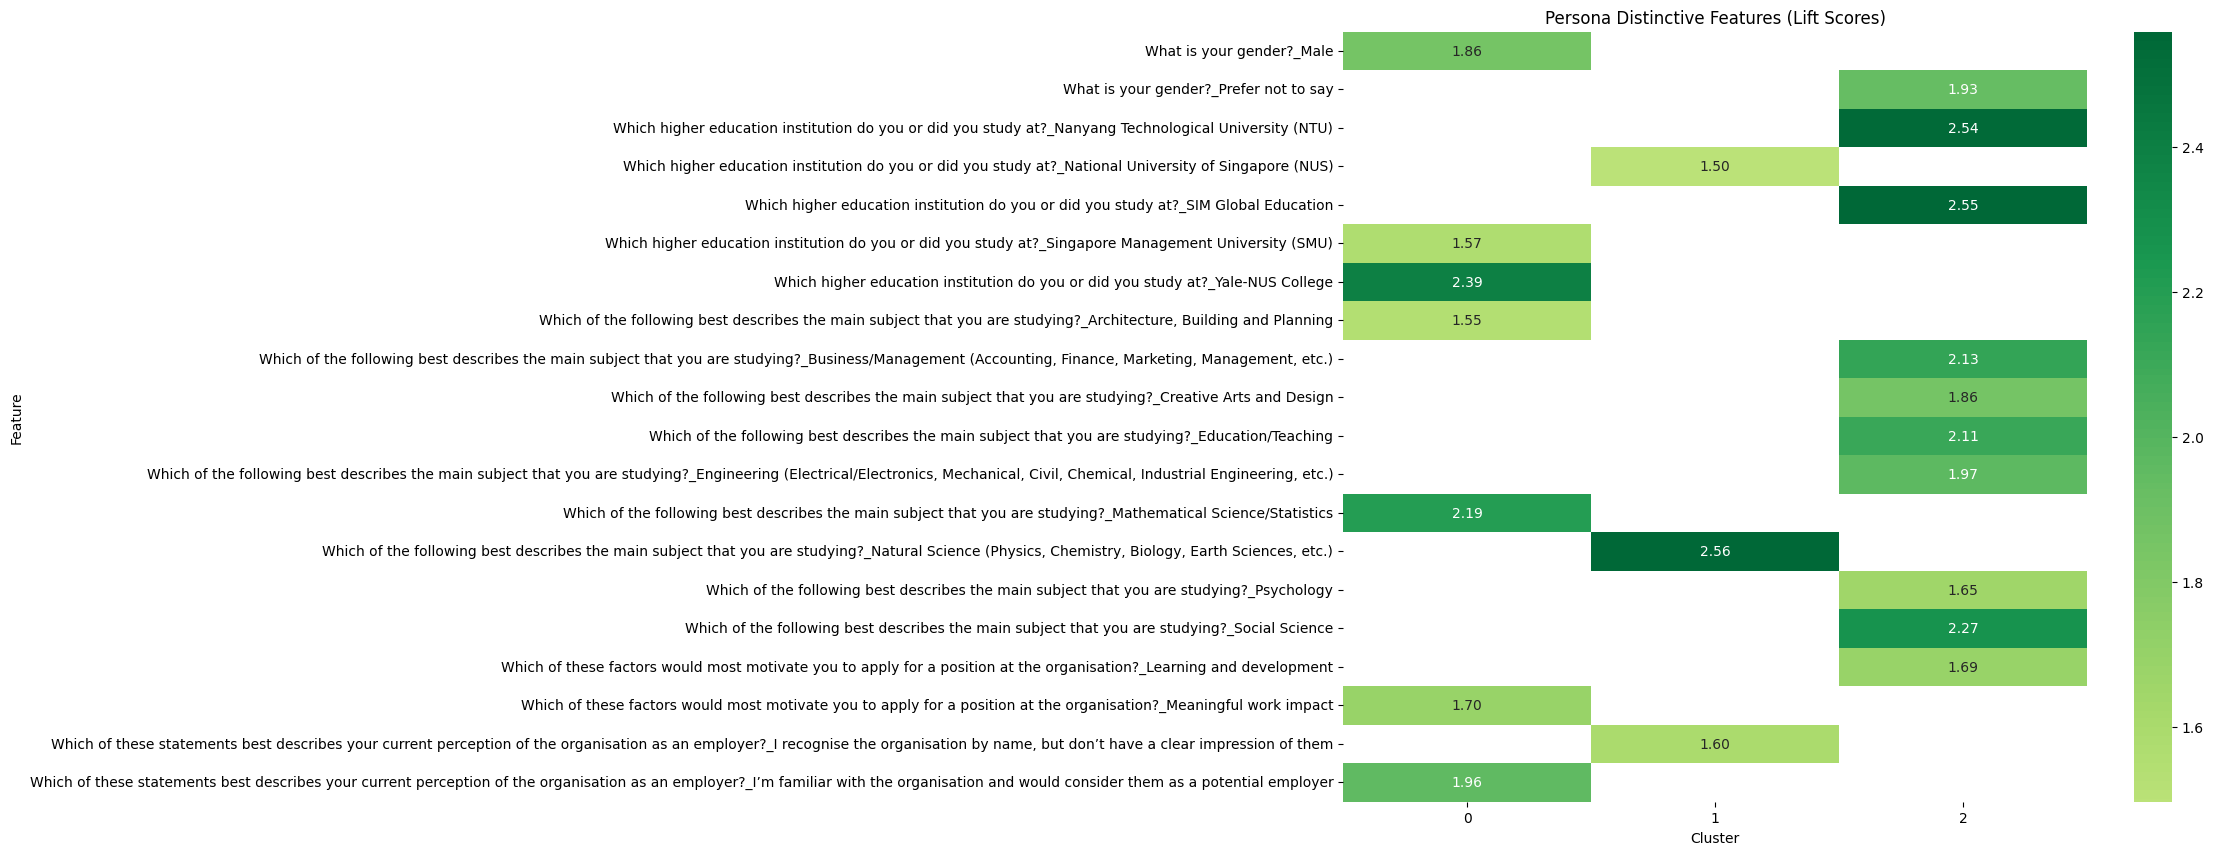

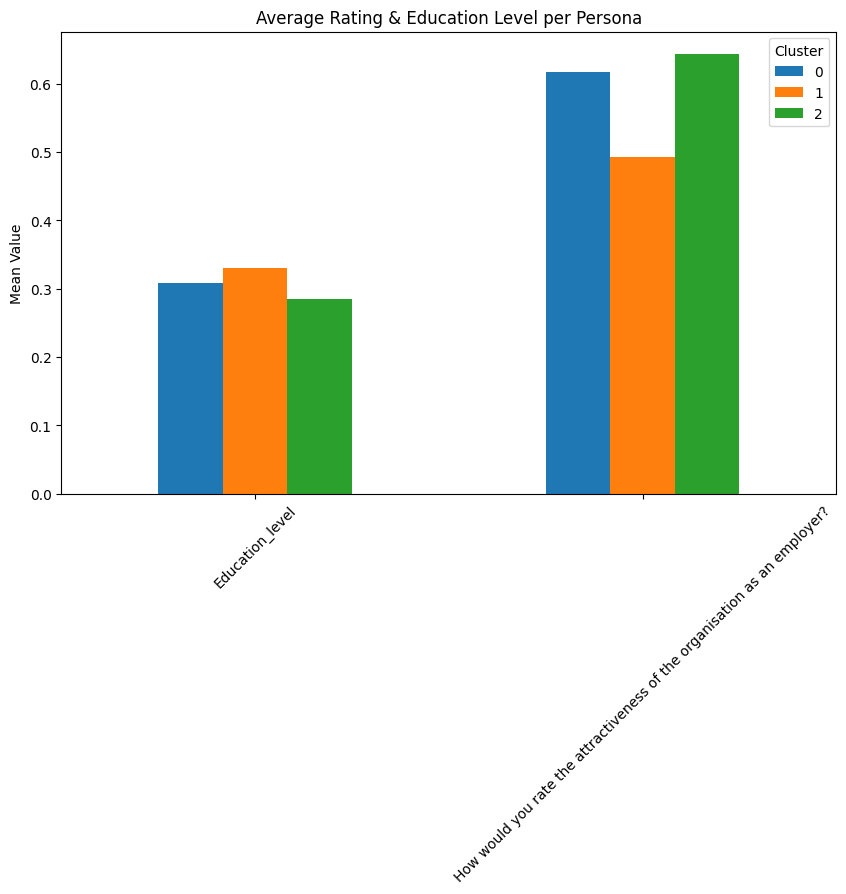

In [ ]:
def get_advanced_cluster_profiles(df, cluster_col, binary_cols, numeric_cols):
    """
    Hybrid Profiling: Calculates Lift for binary columns and Mean Comparison for numeric columns.
    """
    summary_list = []

    # --- 1. Process Numeric Columns (Rating, Education) ---
    print("\n==== Numeric Feature Comparison (Mean Value Analysis) ====")
    # Group by cluster to find the average for each group
    numeric_profile = df.groupby(cluster_col)[numeric_cols].mean()
    # Calculate the global average for comparison
    total_numeric_mean = df[numeric_cols].mean()

    # Print comparison for numeric features
    for col in numeric_cols:
        print(f"\nFeature: {col}")
        for cluster in numeric_profile.index:
            val = numeric_profile.loc[cluster, col]
            diff = val - total_numeric_mean[col]
            # Use arrows to indicate if the cluster is above or below average
            mark = "↑" if diff > 0 else "↓"
            print(f"  Cluster {cluster}: {val:.2f} ({mark} Deviation from Total: {diff:.2f})")

    # --- 2. Process Binary Columns (Survey Yes/No) ---
    total_binary_mean = df[binary_cols].mean()
    binary_results = []

    for k in sorted(df[cluster_col].unique()):
        # Filter data for the specific cluster
        cluster_data = df[df[cluster_col] == k]
        cluster_binary_mean = cluster_data[binary_cols].mean()

        # Calculate Lift (Cluster Ratio / Global Ratio)
        # Lift > 1 means this trait is more prominent in this cluster
        lift = cluster_binary_mean / total_binary_mean

        profile = pd.DataFrame({
            'Cluster': k,
            'Feature': binary_cols,
            'Cluster_Rate': cluster_binary_mean.values,
            'Lift': lift.values
        })

        # Filter out rare features (Total Frequency < 1%) to avoid misleadingly high Lift scores
        profile = profile[total_binary_mean.values > 0.01]

        # Append Top 10 most distinctive features for this cluster
        binary_results.append(profile.sort_values(by='Lift', ascending=False).head(10))

    return pd.concat(binary_results), numeric_profile

# --- Execution ---
# Get raw 0/1 binary columns starting with the survey questions
raw_binary_cols = [c for c in df_1.columns if any(q in c for q in survey_qns) and c not in numeric_cols]

# Run analysis
binary_profiles, numeric_profiles = get_advanced_cluster_profiles(df_1, 'final_cluster', raw_binary_cols, numeric_cols)

plt.figure(figsize=(12, 10))
top_binary_features = binary_profiles.sort_values(by='Lift', ascending=False)['Feature'].unique()[:20]
pivot_lift = binary_profiles[binary_profiles['Feature'].isin(top_binary_features)].pivot(
    index='Feature', columns='Cluster', values='Lift'
)
sns.heatmap(pivot_lift, annot=True, cmap='RdYlGn', center=1, fmt=".2f")
plt.title("Persona Distinctive Features (Lift Scores)")
plt.show()

numeric_profiles.T.plot(kind='bar', figsize=(10, 6))
plt.title("Average Rating & Education Level per Persona")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.show()

In [ ]:
# Run sentence transformer to assist analysis
def get_unique_labels(columns):
    """
    Strips the common survey question prefix to isolate the unique factor.
    Example: 'Question?_Career' becomes 'Career'
    """
    cleaned = []
    for col in columns:
        # If the column has an underscore, take everything after it
        if "Others" in col or "Unknown" in col:
            continue
        elif "_" in col:
            unique_part = col.split("_")[-1]
            cleaned.append(unique_part)
        else:
            cleaned.append(col)
    return cleaned

def check_semantic_redundancy_cleaned(df, threshold=0.70):
    model = SentenceTransformer('all-MiniLM-L6-v2')

    original_columns = df.columns.tolist()
    # Strip the long prefix
    cleaned_labels = get_unique_labels(original_columns)

    # Create a mapping so we know which cleaned label belongs to which column
    label_to_col = dict(zip(cleaned_labels, original_columns))

    embeddings = model.encode(cleaned_labels, convert_to_tensor=True)
    cosine_scores = util.cos_sim(embeddings, embeddings)

    redundant_pairs = []
    for i in range(len(cleaned_labels)):
        for j in range(i + 1, len(cleaned_labels)):
            score = cosine_scores[i][j].item()
            if score > threshold:
                redundant_pairs.append((cleaned_labels[i], cleaned_labels[j], score))

    print(f"--- Refined Redundancy Check (Prefixes Removed) ---")
    if not redundant_pairs:
        print("No redundant questions found after cleaning prefixes.")
    for q1, q2, score in redundant_pairs:
        print(f"Score: {score:.2f} | '{q1}' <--> '{q2}'")

# Run the refined check
check_semantic_redundancy_cleaned(df)

--- Refined Redundancy Check (Prefixes Removed) ---
Score: 0.77 | 'Career progression and development' <--> 'Career growth opportunities'
Score: 0.83 | 'Work-life balance and culture' <--> 'Work-life balance'


### **Discover meaningful demographic or behavioural segments among respondents**

In [ ]:
# Define column groups
cluster_col = 'Position_Cluster_ID'
analysis_df = df.copy()[df['Status'] == "Complete"]

analysis_df.columns = analysis_df.columns.str.replace(
    'Which of these factors would most motivate you to apply for a position at the organisation?_',
    'Motivation Factors - ',
    regex=False
)
analysis_df.columns = [col.replace('What do you wish to learn more about regarding the organisation as an employer?_','Wish to learn as employer - ') for col in analysis_df.columns]

# Motivation Factors (Binary)
motivation_cols = [col for col in analysis_df.columns if col.startswith('Motivation Factors - ')]
# Wish to learn (Binary)
wish_cols = [col for col in analysis_df.columns if col.startswith('Wish to learn as employer - ')]
# Scale/Numerical questions
scale_cols = [
    'On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?',
    'Education_level'
]
# Categorical questions
cat_cols = [
    'What is your gender?',
    'Please indicate your nationality.',
    'Which of the following best describes the main subject that you are studying?',
    'Which of these statements best describes your current perception of the organisation as an employer?'
]

# Labels
labels = {'On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?': "Attractiveness Score",
        'Education_level': "Education Level"}

analysis_df.head()

,Response ID,Time Started,Date Submitted,Status,Which higher education institution do you or did you study at?,Which of the following best describes the main subject that you are studying?,Please indicate your nationality.,What is your gender?,Which of these statements best describes your current perception of the organisation as an employer?,"On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?",...,Education_level,Position_Cluster_ID,Motivation Factors - Career growth opportunities,Motivation Factors - Compensation package,Motivation Factors - Job security,Motivation Factors - Learning and development,Motivation Factors - Meaningful work impact,Motivation Factors - Others,Motivation Factors - Unknown,Motivation Factors - Work-life balance
3,22,2025-09-03 15:25:18,2025-09-03 15:27:05,Complete,Nanyang Technological University (NTU),Economics,Singaporean/Singapore PR,Female,I’m familiar with the organisation and would consider them as a potential employer,0.777778,...,0.40,1.0,0,0,0,0,1,0,0,0
9,28,2025-09-04 13:25:41,2025-09-04 17:50:12,Complete,Nanyang Technological University (NTU),"Business/Management (Accounting, Finance, Marketing, Management, etc.)",Singaporean/Singapore PR,Female,"I recognise the organisation by name, but don’t have a clear impression of them",0.555556,...,0.35,3.0,0,0,0,0,1,0,0,0
13,32,2025-09-04 15:18:25,2025-09-04 15:19:23,Complete,Nanyang Technological University (NTU),"Business/Management (Accounting, Finance, Marketing, Management, etc.)",Singaporean/Singapore PR,Female,"I have a general positive impression of the organisation, but don’t know much about what jobs they offer",0.666667,...,0.35,3.0,1,0,0,0,0,0,0,0
16,35,2025-09-05 00:38:26,2025-10-16 13:56:34,Complete,Nanyang Technological University (NTU),Psychology,Singaporean/Singapore PR,Female,"I have a general positive impression of the organisation, but don’t know much about what jobs they offer",0.444444,...,0.30,4.0,0,0,0,0,1,0,0,0
17,36,2025-09-05 14:34:27,2025-09-05 14:36:52,Complete,Singapore Management University (SMU),"Business/Management (Accounting, Finance, Marketing, Management, etc.)",Singaporean/Singapore PR,Female,"I recognise the organisation by name, but don’t have a clear impression of them",0.777778,...,0.30,8.0,0,0,0,0,1,0,0,0


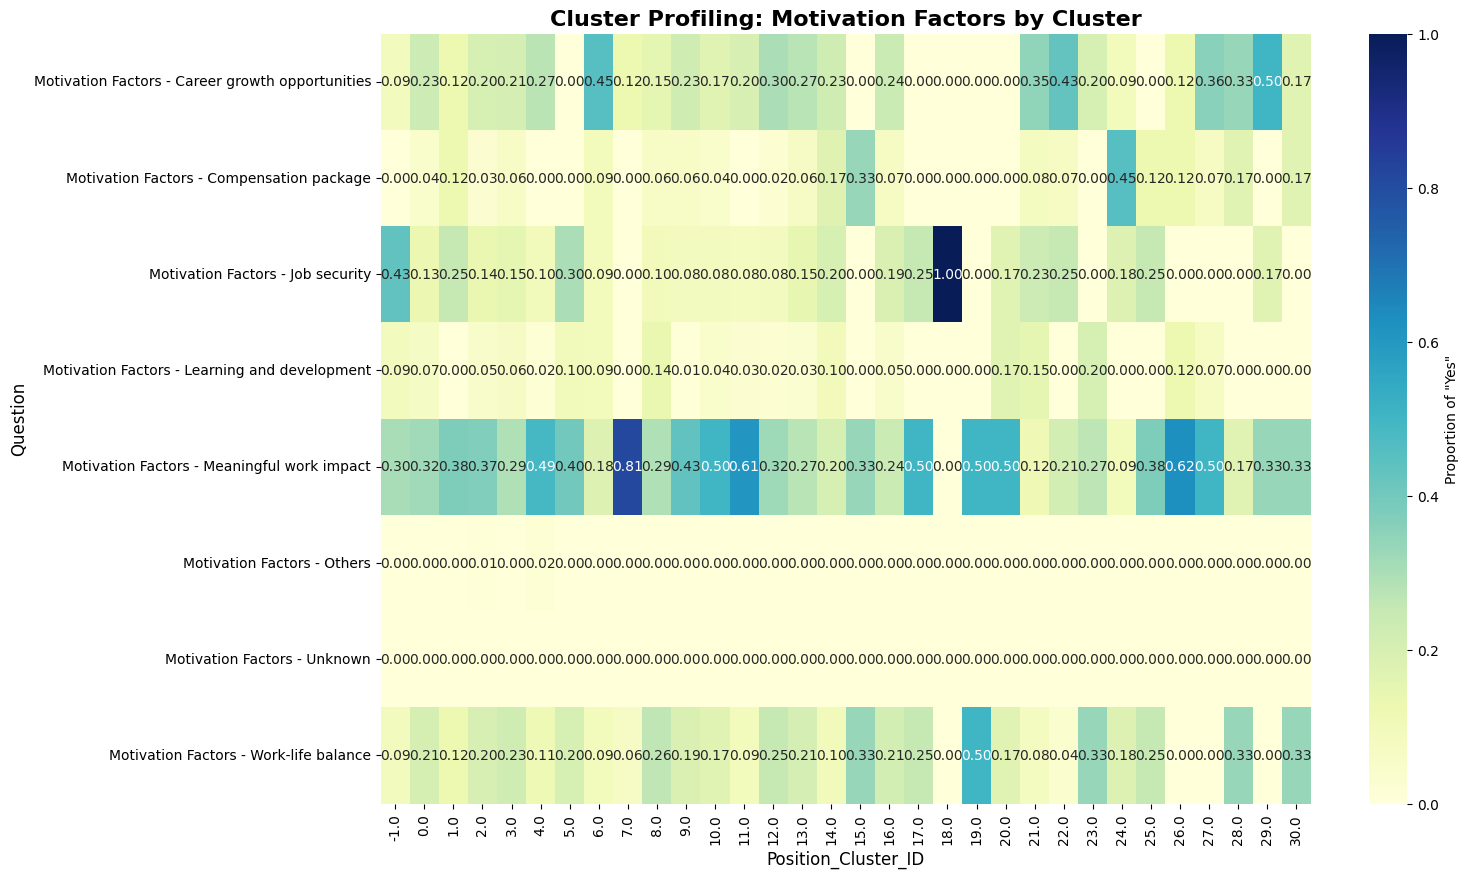

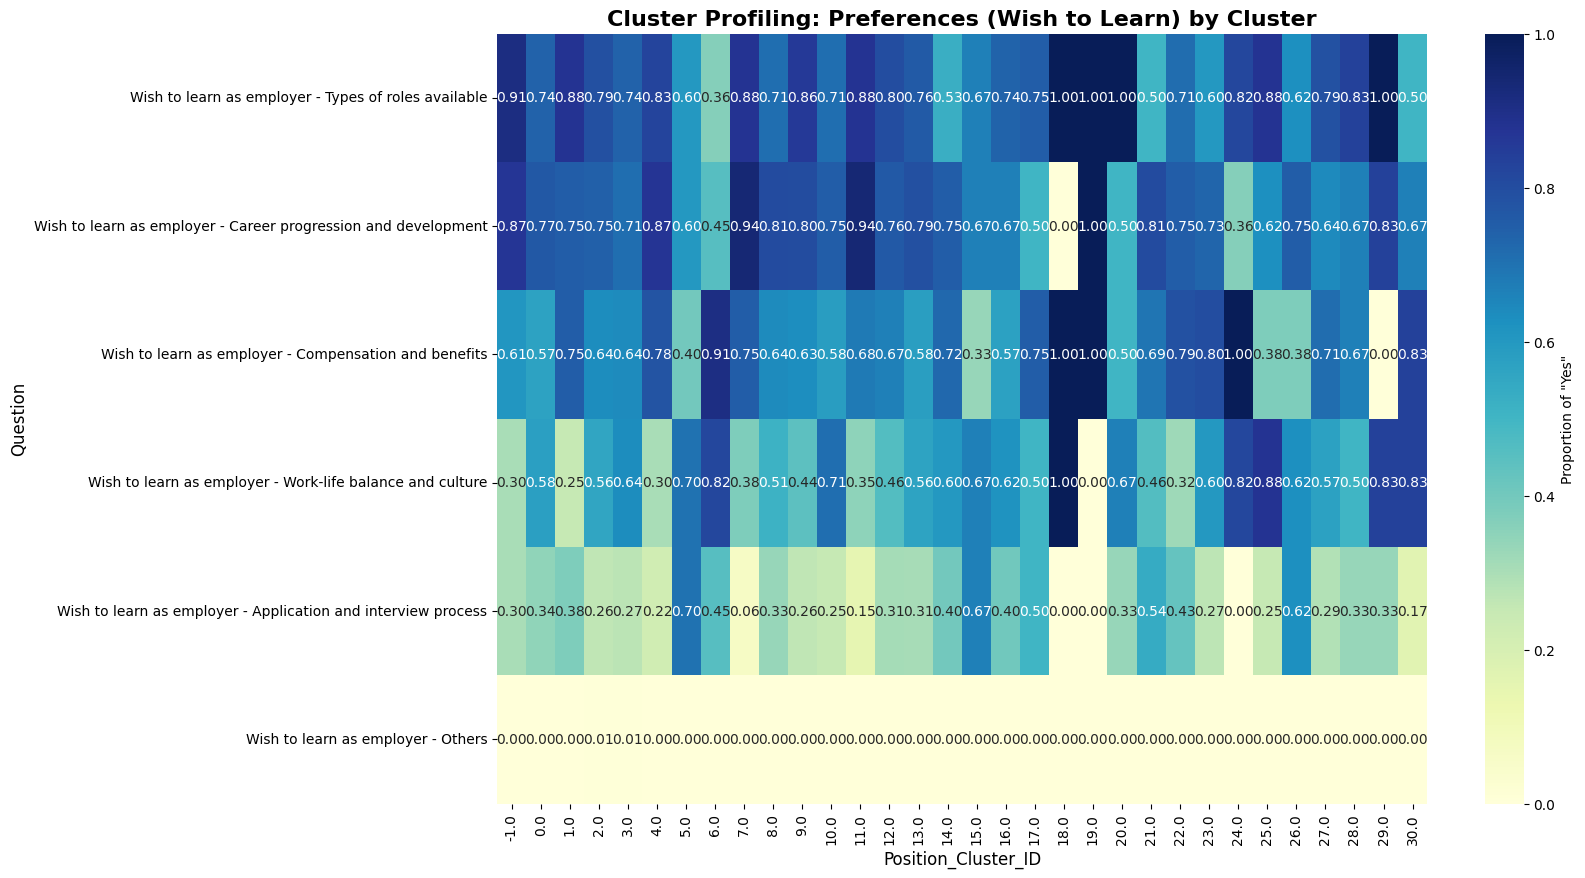

In [ ]:
# --- 1. Heatmap for Binary Questions (Motivation & Wish to Learn) ---
def plot_binary_heatmap(cols, title):
    if not cols: return
    # Calculate % of 'Yes' (1) per cluster
    cluster_profile = analysis_df.groupby(cluster_col)[cols].mean()

    plt.figure(figsize=(15, 10))
    sns.heatmap(cluster_profile.T, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Proportion of "Yes"'})
    plt.title(f'Cluster Profiling: {title}', fontsize=16, fontweight='bold')
    plt.xlabel('Position_Cluster_ID', fontsize=12)
    plt.ylabel('Question', fontsize=12)
    plt.show()

plot_binary_heatmap(motivation_cols, "Motivation Factors by Cluster")
plot_binary_heatmap(wish_cols, "Preferences (Wish to Learn) by Cluster")

/var/folders/qv/xzq6rspd7nv2j8g1qndx4g800000gn/T/ipykernel_17856/215132913.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analysis_df, x=cluster_col, y=col, palette='Set3', errorbar=None)


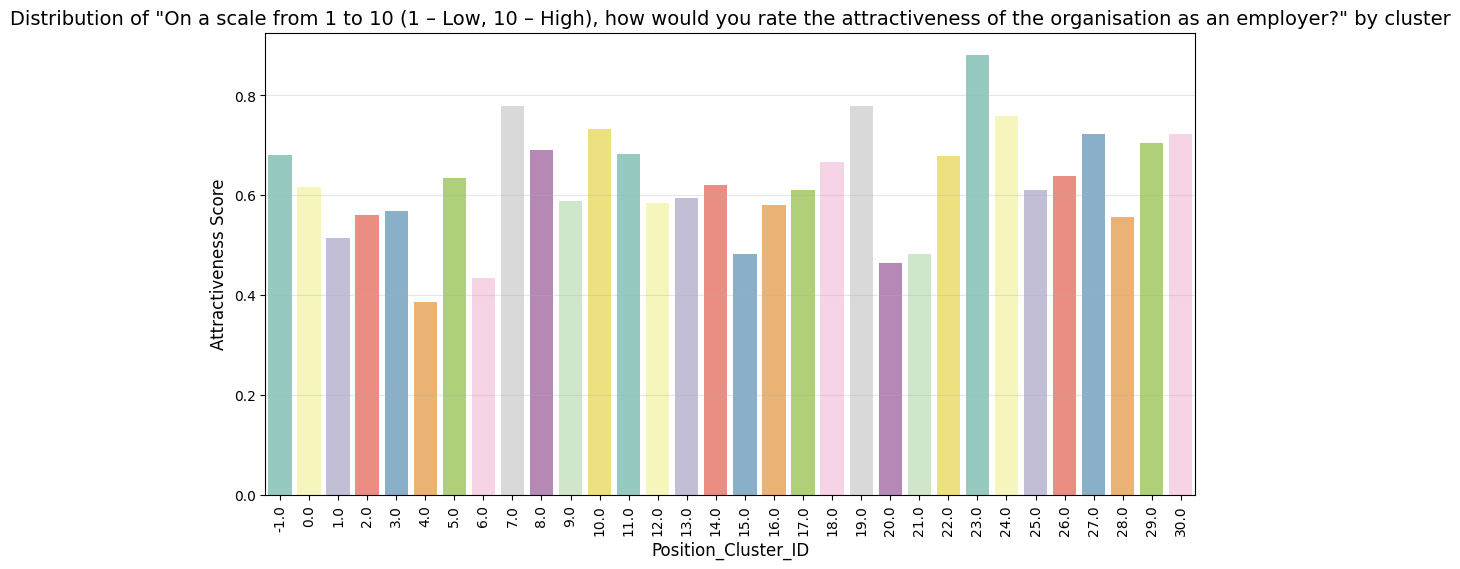

/var/folders/qv/xzq6rspd7nv2j8g1qndx4g800000gn/T/ipykernel_17856/215132913.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analysis_df, x=cluster_col, y=col, palette='Set3', errorbar=None)


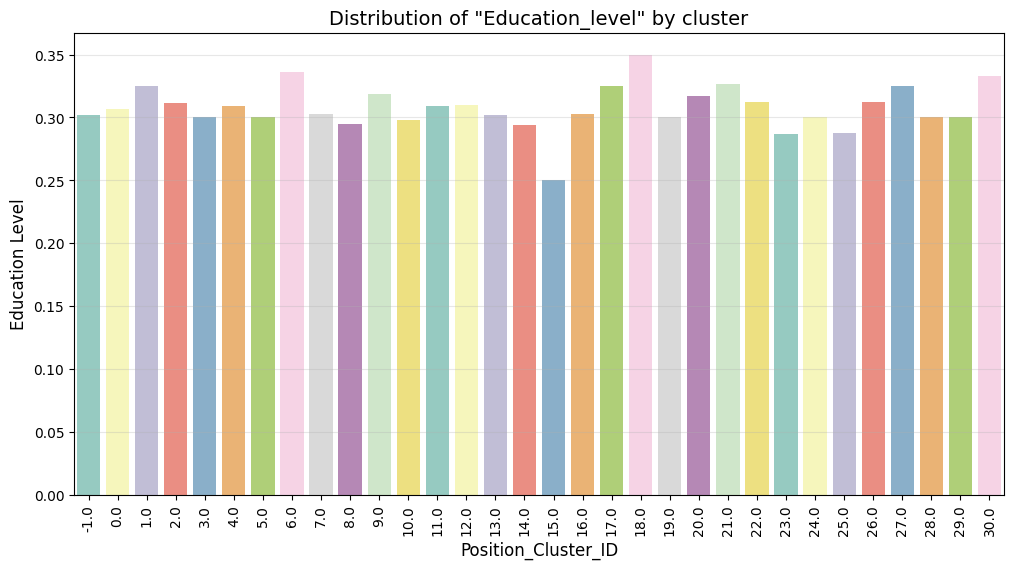

In [ ]:
# --- 2. Numerical/Scale Questions (Barplots) ---

for col in scale_cols:
    if col in df.columns:
        plt.figure(figsize=(12, 6))
        sns.barplot(data=analysis_df, x=cluster_col, y=col, palette='Set3', errorbar=None)
        plt.xticks(rotation=90)
        plt.xlabel('Position_Cluster_ID', fontsize=12)
        plt.ylabel(labels.get(col), fontsize=12)
        plt.title(f'Distribution of "{col}" by cluster', fontsize=14)
        plt.grid(axis='y', alpha=0.3)
        plt.show()


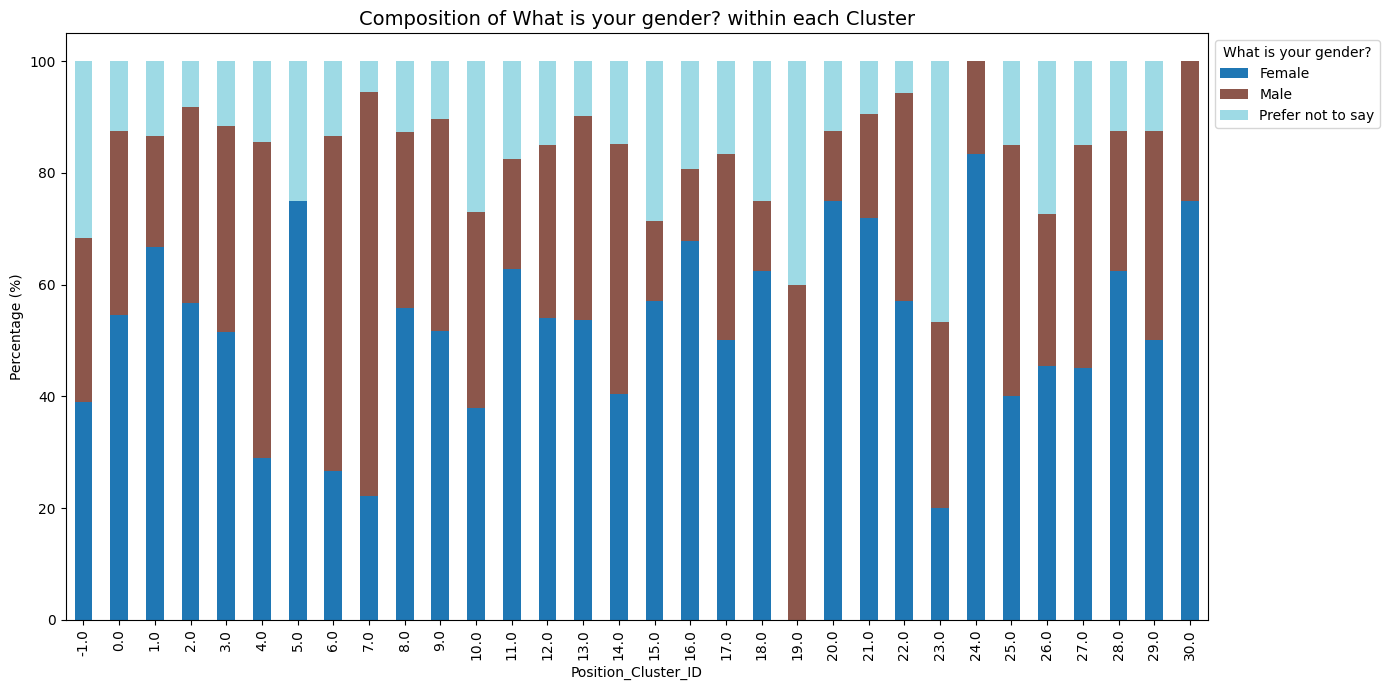

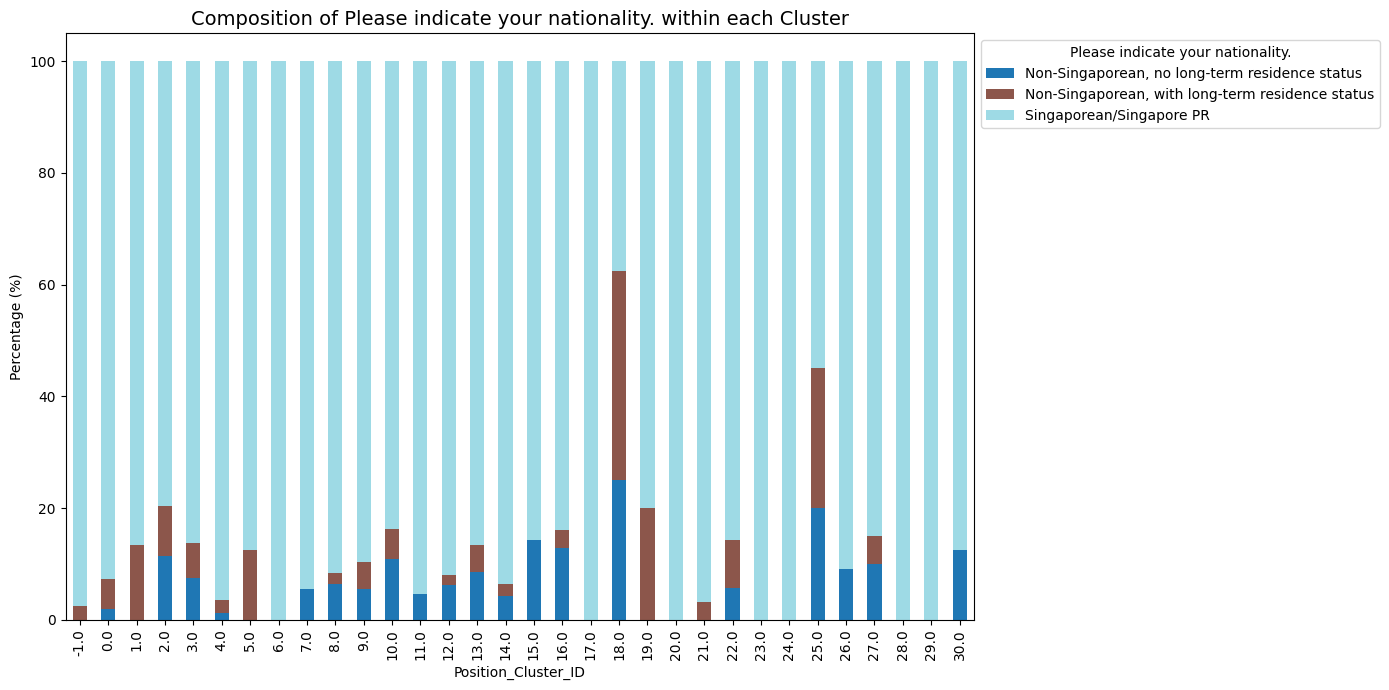

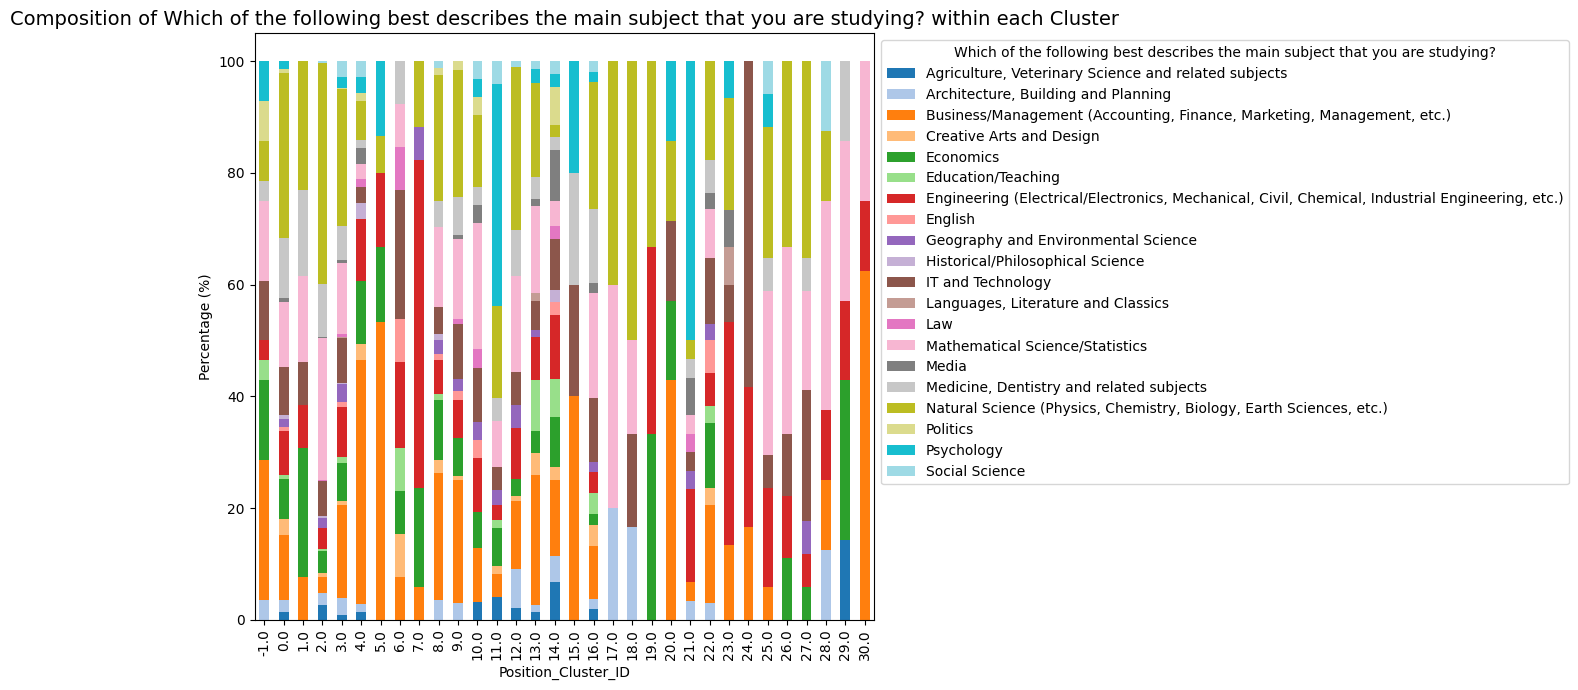

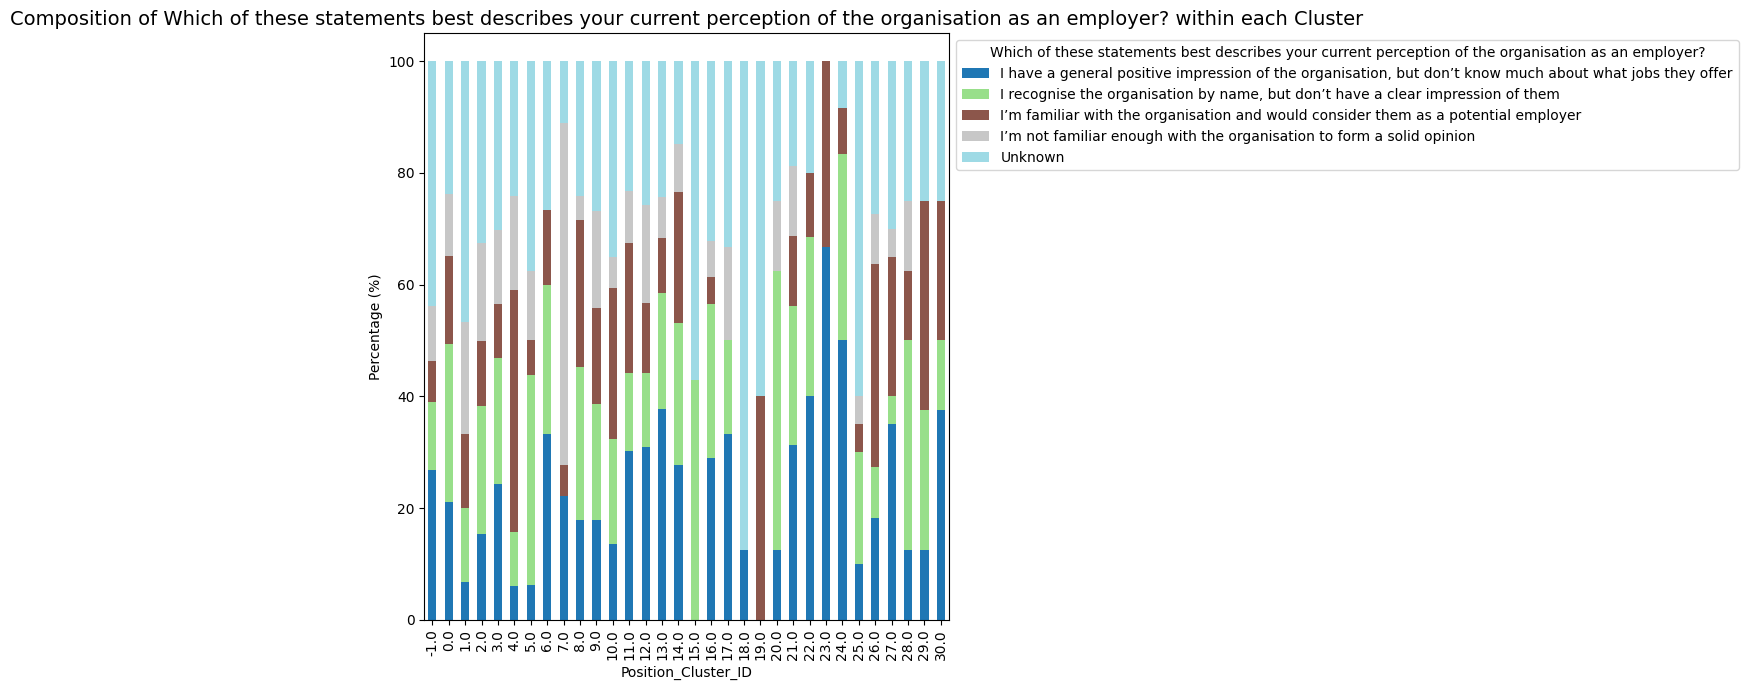

In [ ]:
# --- 3. Categorical Questions (Proportional Bar Charts) ---
# We use proportions instead of raw counts because cluster sizes vary significantly
for col in cat_cols:
    if col in df.columns:
        # Create a cross-tabulation and normalize by row (cluster)
        ct = pd.crosstab(df[cluster_col], df[col], normalize='index') * 100

        ax = ct.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20')
        plt.title(f'Composition of {col} within each Cluster', fontsize=14)
        plt.ylabel('Percentage (%)')
        plt.xlabel('Position_Cluster_ID')
        plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', title=col)
        plt.tight_layout()
        plt.show()


### **Understand factors associated with partial or incomplete survey responses**

In [ ]:
df_2 = df.copy()

df_2.columns = analysis_df.columns.str.replace(
    'Which of these factors would most motivate you to apply for a position at the organisation?_',
    'Motivation Factors - ',
    regex=False
)
df_2.columns = [col.replace('What do you wish to learn more about regarding the organisation as an employer?_','Wish to learn as employer - ') for col in analysis_df.columns]
df_2['completed'] = (df_2['Status'] == 'Complete').astype(int)

feature_cols = [
    'On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?',
    'Motivation Factors - Career growth opportunities',
    'Motivation Factors - Compensation package',
    'Motivation Factors - Job security',
    'Motivation Factors - Learning and development',
    'Motivation Factors - Meaningful work impact',
    'Motivation Factors - Work-life balance',
    'Wish to learn as employer - Types of roles available',
    'Wish to learn as employer - Career progression and development',
    'Wish to learn as employer - Compensation and benefits',
    'Wish to learn as employer - Work-life balance and culture',
    'Wish to learn as employer - Application and interview process'
]

X = df_2[feature_cols].fillna(0)
y = df_2['completed']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='liblinear'
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

coef_df = coef_df.sort_values('Odds_Ratio', ascending=False)
coef_df

,Feature,Coefficient,Odds_Ratio
7,Wish to learn as employer - Types of roles available,1.894154,6.646925
8,Wish to learn as employer - Career progression and development,1.873746,6.512649
9,Wish to learn as employer - Compensation and benefits,1.723058,5.601635
10,Wish to learn as employer - Work-life balance and culture,1.690512,5.422255
11,Wish to learn as employer - Application and interview process,1.338679,3.814002
5,Motivation Factors - Meaningful work impact,0.900344,2.460449
6,Motivation Factors - Work-life balance,0.713462,2.041045
1,Motivation Factors - Career growth opportunities,0.710453,2.034913
3,Motivation Factors - Job security,0.658977,1.932814
2,Motivation Factors - Compensation package,0.379147,1.461037


/var/folders/qv/xzq6rspd7nv2j8g1qndx4g800000gn/T/ipykernel_17856/2466753448.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


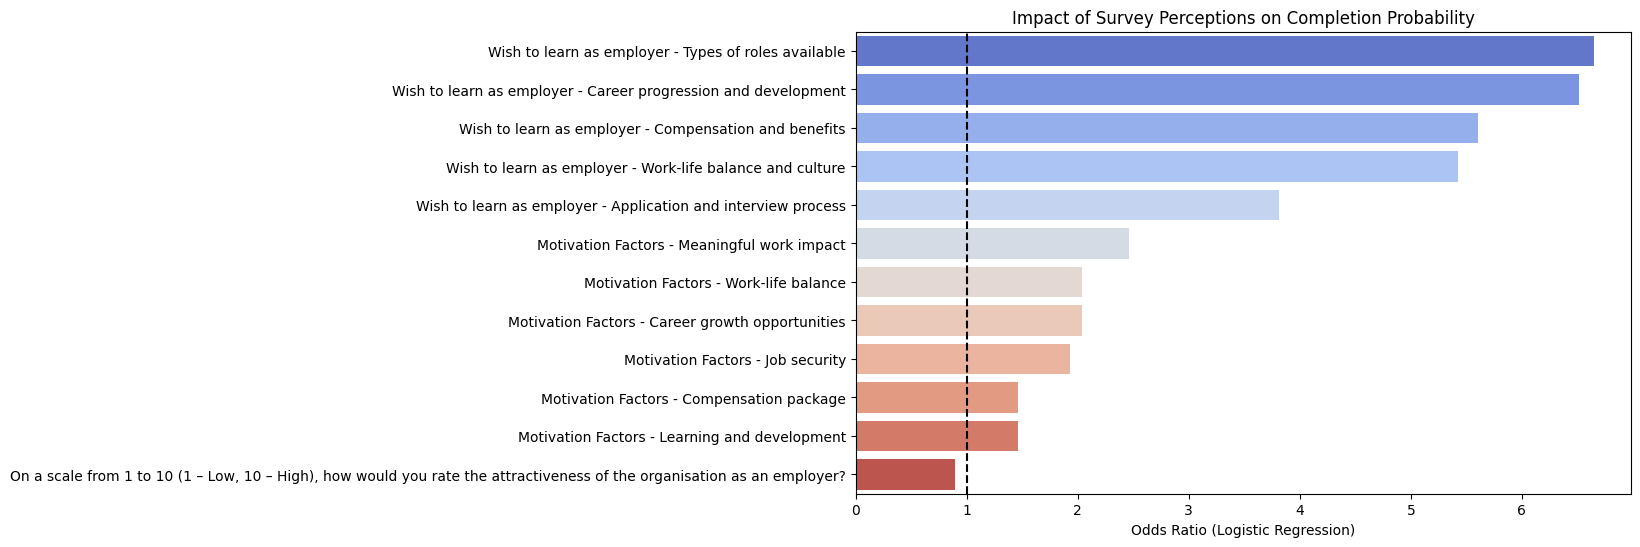

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df,
    x='Odds_Ratio',
    y='Feature',
    palette='coolwarm'
)
plt.axvline(1, color='black', linestyle='--')
plt.title('Impact of Survey Perceptions on Completion Probability')
plt.xlabel('Odds Ratio (Logistic Regression)')
plt.ylabel('')
plt.show()

In [ ]:
df['Time Started'] = pd.to_datetime(df['Time Started'])
df['Date Submitted'] = pd.to_datetime(df['Date Submitted'])

df['time_taken_seconds'] = (df['Date Submitted'] - df['Time Started']).dt.total_seconds()
df['time_taken_minutes'] = df['time_taken_seconds'] / 60

df = df[df['time_taken_seconds'] > 0]

/var/folders/qv/xzq6rspd7nv2j8g1qndx4g800000gn/T/ipykernel_17856/2265101611.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


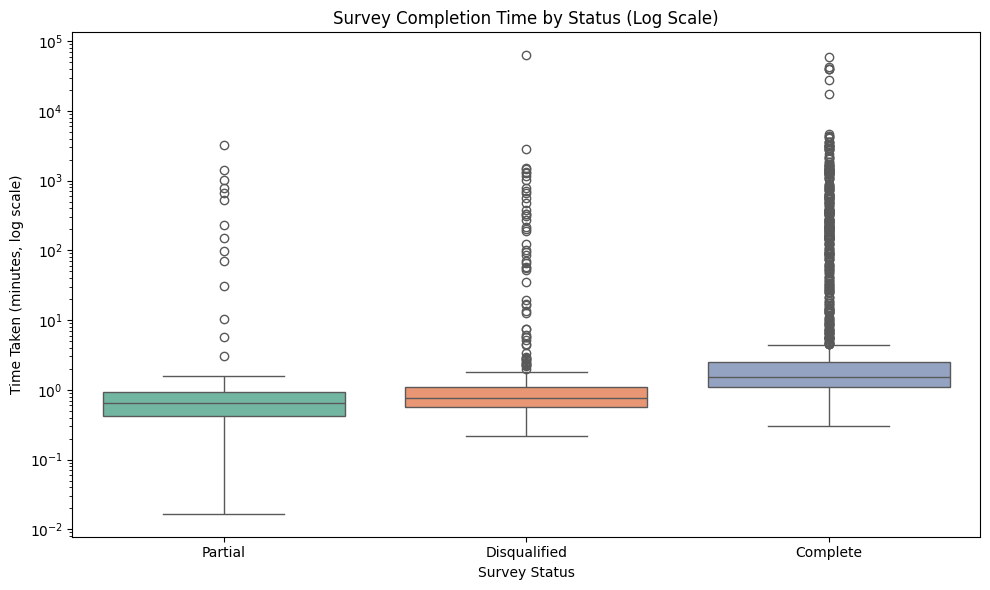

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Status',
    y='time_taken_minutes',
    palette='Set2'
)

plt.yscale('log')  # Log scale to handle long tails
plt.title('Survey Completion Time by Status (Log Scale)')
plt.ylabel('Time Taken (minutes, log scale)')
plt.xlabel('Survey Status')
plt.tight_layout()
plt.show()

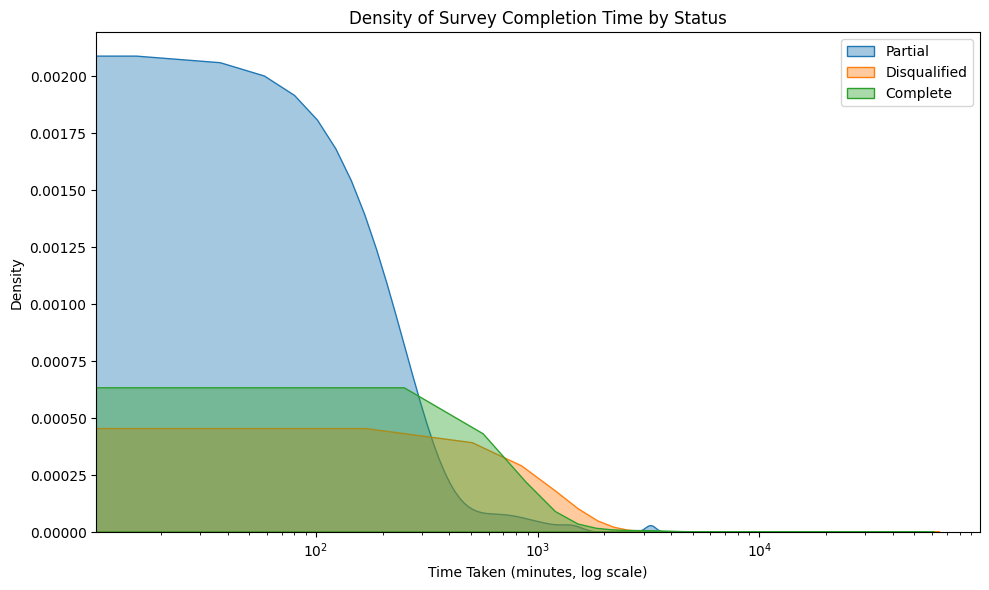

In [ ]:
plt.figure(figsize=(10, 6))

for status in df['Status'].unique():
    sns.kdeplot(
        df[df['Status'] == status]['time_taken_minutes'],
        label=status,
        fill=True,
        alpha=0.4
    )

plt.xscale('log')
plt.title('Density of Survey Completion Time by Status')
plt.xlabel('Time Taken (minutes, log scale)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('Status')['time_taken_minutes'].describe()[[
    'count', 'mean', '50%', 'std'
]].rename(columns={'50%': 'median'})

,count,mean,median,std
Status,,,,
Complete,1848.0,242.795337,1.516667,2481.768108
Disqualified,465.0,171.232903,0.766667,2905.568312
Partial,81.0,101.981481,0.650000,419.276817


In [ ]:
groups = [
    df[df['Status'] == status]['time_taken_minutes']
    for status in df['Status'].unique()
]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis Statistic: {stat:.3f}")
print(f"P-value: {p_value:.5f}")

Kruskal-Wallis Statistic: 415.868
P-value: 0.00000


In [ ]:
groups = {
    status: df.loc[df['Status'] == status, 'time_taken_minutes'].dropna()
    for status in df['Status'].unique()
}
results = []

pairs = list(itertools.combinations(groups.keys(), 2))

for g1, g2 in pairs:
    stat, p = mannwhitneyu(groups[g1], groups[g2], alternative='two-sided')
    results.append({
        'Group 1': g1,
        'Group 2': g2,
        'U statistic': stat,
        'p-value (raw)': p
    })

posthoc_df = pd.DataFrame(results)
posthoc_df['p-value (bonferroni)'] = posthoc_df['p-value (raw)'] * len(posthoc_df)
posthoc_df['p-value (bonferroni)'] = posthoc_df['p-value (bonferroni)'].clip(upper=1)

In [ ]:
H = 415.868
n = df['time_taken_minutes'].notna().sum()
k = df['Status'].nunique()

eta_squared = (H - k + 1) / (n - k)
eta_squared

np.float64(0.17309410288582183)

/var/folders/qv/xzq6rspd7nv2j8g1qndx4g800000gn/T/ipykernel_17856/532250301.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['time_bucket', 'Status'])


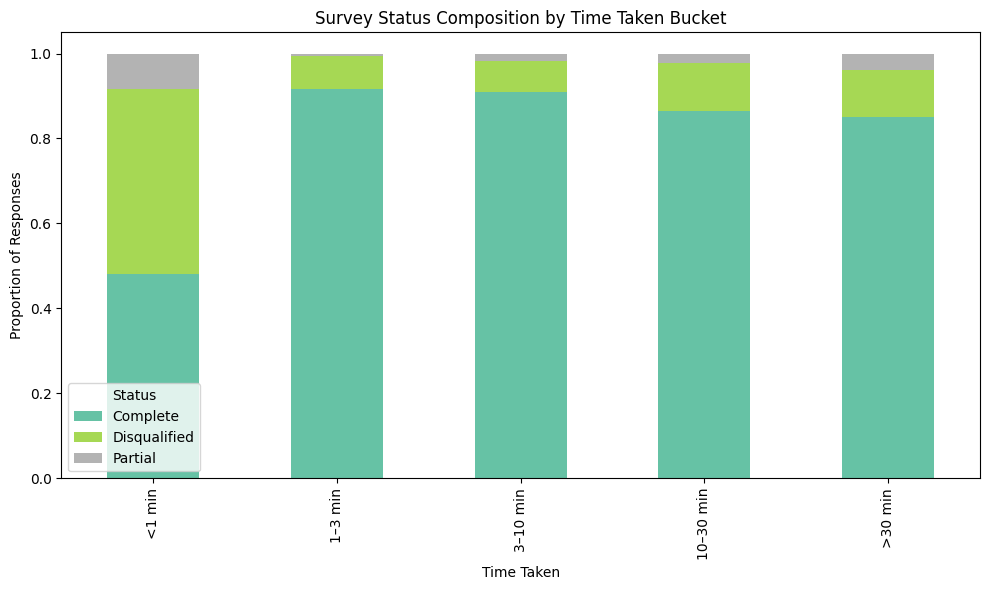

In [ ]:
df['time_bucket'] = pd.cut(
    df['time_taken_minutes'],
    bins=[0, 1, 3, 10, 30, np.inf],
    labels=[
        '<1 min',
        '1–3 min',
        '3–10 min',
        '10–30 min',
        '>30 min'
    ]
)
bucket_status = (
    df.groupby(['time_bucket', 'Status'])
      .size()
      .unstack(fill_value=0)
)

bucket_status_pct = bucket_status.div(bucket_status.sum(axis=1), axis=0)

bucket_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='Set2'
)

plt.title('Survey Status Composition by Time Taken Bucket')
plt.ylabel('Proportion of Responses')
plt.xlabel('Time Taken')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [ ]:
X = df[['time_taken_minutes']]
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

Train accuracy: 0.8202985074626866
Test accuracy: 0.7969401947148818


### **Extract insights from the applicant’s perspective on what drives employer attractiveness**


Attractiveness Score Statistics:
  Mean: 0.59
  Median: 0.56
  Std Dev: 0.23
  Min: 0.0, Max: 1.0
  Skewness: -0.35
  Kurtosis: -0.10
  Distribution is approximately symmetric

Score Distribution:
On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?
0.000000     38
0.111111     70
0.222222     86
0.333333     89
0.444444    354
0.555556    320
0.666667    367
0.777778    281
0.888889    123
1.000000    120
Name: count, dtype: int64


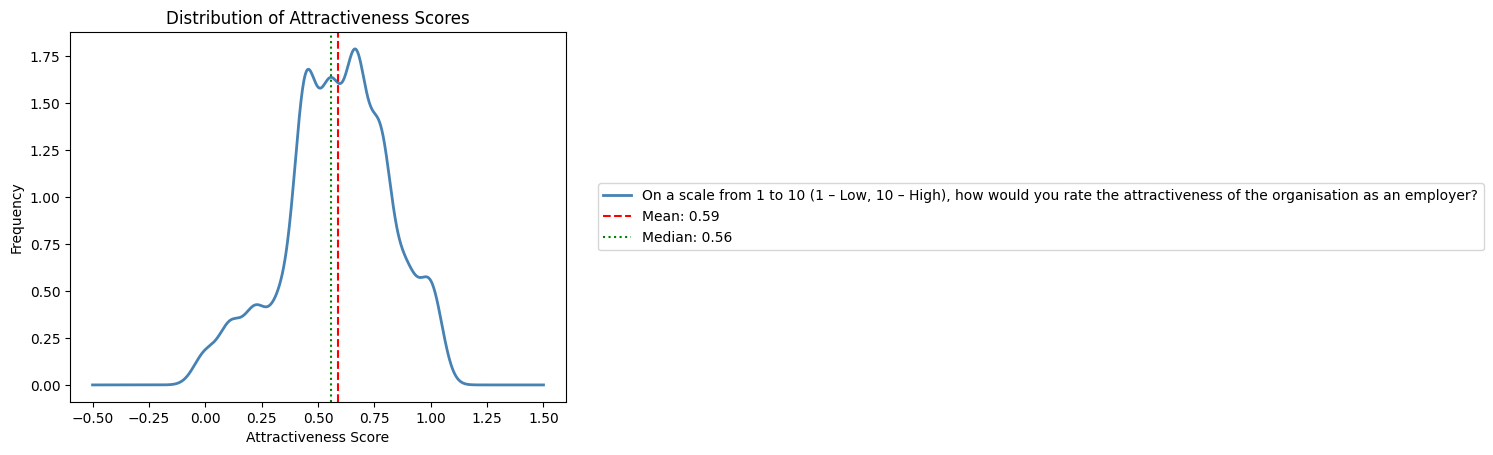

In [ ]:
model_df = analysis_df.copy()

scores = model_df['On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?']

print(f"\nAttractiveness Score Statistics:")
print(f"  Mean: {scores.mean():.2f}")
print(f"  Median: {scores.median():.2f}")
print(f"  Std Dev: {scores.std():.2f}")
print(f"  Min: {scores.min()}, Max: {scores.max()}")
print(f"  Skewness: {stats.skew(scores):.2f}")
print(f"  Kurtosis: {stats.kurtosis(scores):.2f}")

skewness = stats.skew(scores)
if skewness > 0.5:
    print("  Distribution is positively skewed (right-tailed)")
elif skewness < -0.5:
    print("  Distribution is negatively skewed (left-tailed)")
else:
    print("  Distribution is approximately symmetric")

print(f"\nScore Distribution:")
print(scores.value_counts().sort_index())

fig, axes = plt.subplots()

scores.plot(kind='kde', ax=axes, color='steelblue', linewidth=2)
axes.axvline(scores.mean(), color='red', linestyle='--', label=f'Mean: {scores.mean():.2f}')
axes.axvline(scores.median(), color='green', linestyle=':', label=f'Median: {scores.median():.2f}')
axes.set_xlabel('Attractiveness Score')
axes.set_ylabel('Frequency')
axes.set_title('Distribution of Attractiveness Scores')
axes.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')  # Outside the plot area

plt.show()


In [ ]:
# Identify target variable
target_col = 'On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?'

# List categorical columns that need encoding
categorical_cols = [
    'Which higher education institution do you or did you study at?',
    'Which of the following best describes the main subject that you are studying?',
    'Please indicate your nationality.',
    'What is your gender?',
    'Which of these statements best describes your current perception of the organisation as an employer?'
]

le = LabelEncoder()
for col in categorical_cols:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

# Define the exact feature set requested by the user
requested_features = [
    'Which higher education institution do you or did you study at?',
    'Which of the following best describes the main subject that you are studying?',
    'Please indicate your nationality.',
    'What is your gender?',
    'Which of these statements best describes your current perception of the organisation as an employer?',
    'Wish to learn as employer - Types of roles available',
    'Wish to learn as employer - Career progression and development',
    'Wish to learn as employer - Compensation and benefits',
    'Wish to learn as employer - Work-life balance and culture',
    'Wish to learn as employer - Application and interview process',
    'Wish to learn as employer - Others',
    'Education_level',
    'Motivation Factors - Career growth opportunities',
    'Motivation Factors - Compensation package',
    'Motivation Factors - Job security',
    'Motivation Factors - Learning and development',
    'Motivation Factors - Meaningful work impact',
    'Motivation Factors - Others',
    'Motivation Factors - Unknown',
    'Motivation Factors - Work-life balance'
]

X = model_df[requested_features]
y = model_df[target_col]
feature_names = requested_features

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X = model_df[requested_features]
y = model_df[target_col]
feature_names = requested_features

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTrain set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Ensure y is numeric type just in case
    y_train_num = y_train.astype(float)
    y_test_num = y_test.astype(float)

    model.fit(X_train, y_train_num)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test_num, y_pred))
    mae = mean_absolute_error(y_test_num, y_pred)
    r2 = r2_score(y_test_num, y_pred)

    cv_scores = cross_val_score(model, X, y.astype(float), cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores.mean())

    results[name] = {
        'model': model,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'CV_RMSE': cv_rmse
    }

    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE: {mae:.3f}")
    print(f"  R2: {r2:.3f}")
    print(f"  CV RMSE: {cv_rmse:.3f}")

print("MODEL COMPARISON SUMMARY")

comparison_df = pd.DataFrame({
    name: {'RMSE': res['RMSE'], 'MAE': res['MAE'], 'R2': res['R2'], 'CV_RMSE': res['CV_RMSE']}
    for name, res in results.items()
}).T
print(comparison_df.round(3))


Train set: 1478 samples
Test set: 370 samples

Training Linear Regression...
  RMSE: 0.224
  MAE: 0.179
  R2: 0.077
  CV RMSE: 0.228

Training Ridge Regression...
  RMSE: 0.224
  MAE: 0.179
  R2: 0.078
  CV RMSE: 0.228

Training Random Forest...
  RMSE: 0.214
  MAE: 0.163
  R2: 0.157
  CV RMSE: 0.222

Training Gradient Boosting...
  RMSE: 0.213
  MAE: 0.164
  R2: 0.165
  CV RMSE: 0.225
MODEL COMPARISON SUMMARY
                    RMSE    MAE     R2  CV_RMSE
Linear Regression  0.224  0.179  0.077    0.228
Ridge Regression   0.224  0.179  0.078    0.228
Random Forest      0.214  0.163  0.157    0.222
Gradient Boosting  0.213  0.164  0.165    0.225



Top 15 Most Important Features (Random Forest):
                                                                                             Feature  Importance
Which of these statements best describes your current perception of the organisation as an employer?    0.281760
                                      Which higher education institution do you or did you study at?    0.204188
                       Which of the following best describes the main subject that you are studying?    0.180178
                                                                                     Education_level    0.059421
                                                                                What is your gender?    0.040775
                                                Wish to learn as employer - Types of roles available    0.040053
                                                         Motivation Factors - Meaningful work impact    0.024985
                                      Wish to l

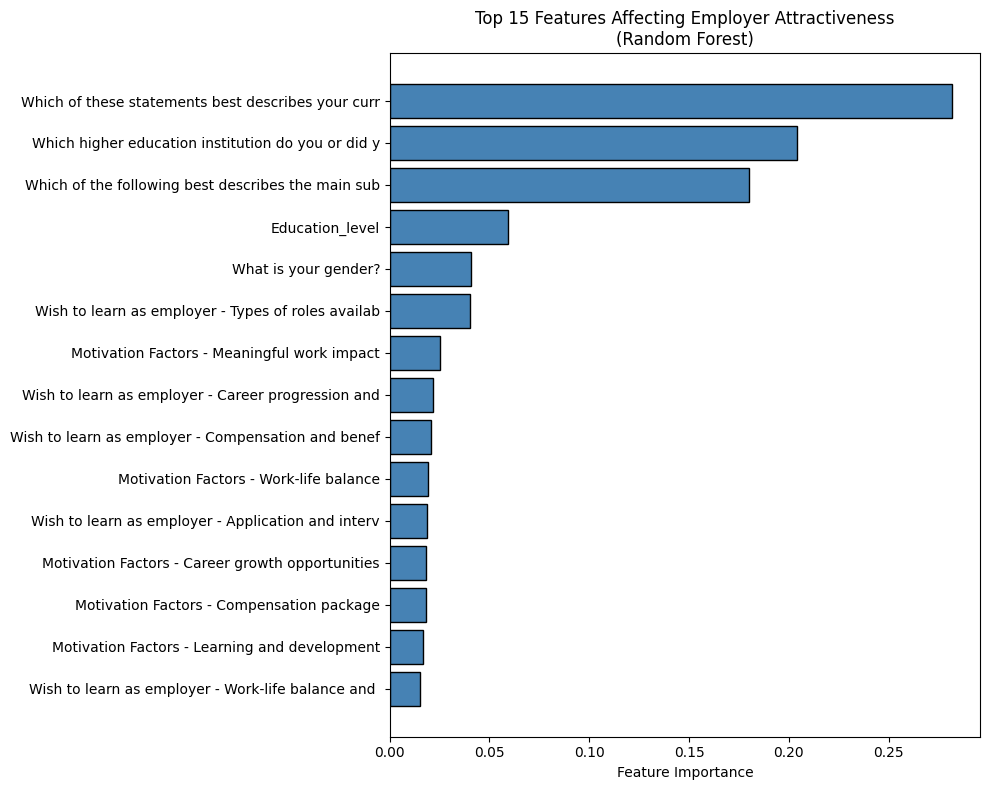

In [ ]:
rf_model = results['Gradient Boosting']['model']
importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features (Random Forest):")
print(importance_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top_features = importance_df.head(15)
bars = ax.barh(range(len(top_features)), top_features['Importance'], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([str(f)[:50] for f in top_features['Feature']])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features Affecting Employer Attractiveness\n(Random Forest)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

/var/folders/qv/xzq6rspd7nv2j8g1qndx4g800000gn/T/ipykernel_17856/1270954204.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean', y=filtered_subject_scores.index, data=filtered_subject_scores.reset_index(), palette='Blues_d')


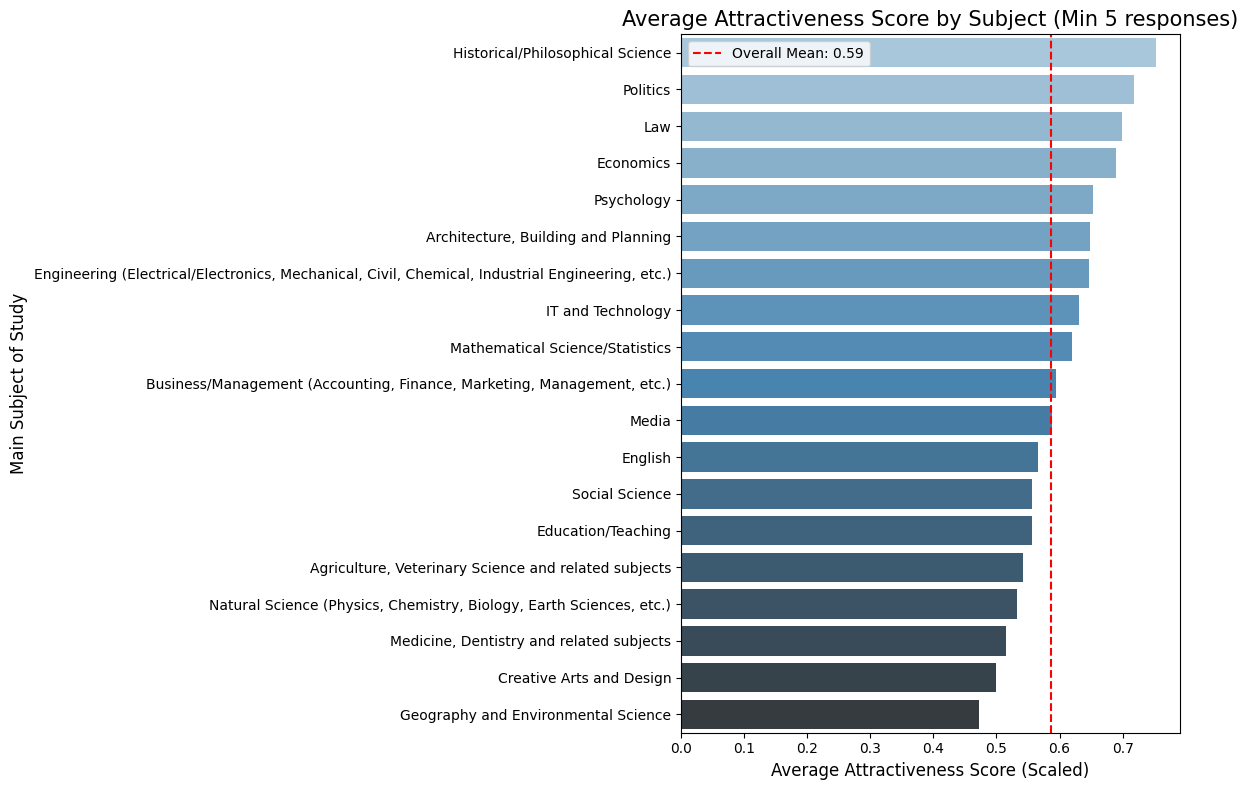

In [ ]:
# Analysis of Attractiveness by Subject of Study
feature_subject = 'Which of the following best describes the main subject that you are studying?'
min_responses = 5 # Filter out subjects with very few responses for statistical relevance

# Calculate mean, count, and std
subject_scores = analysis_df.groupby(feature_subject)[target_col].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False)

# Filter for relevance
filtered_subject_scores = subject_scores[subject_scores['count'] >= min_responses]

plt.figure(figsize=(12, 8))
sns.barplot(x='mean', y=filtered_subject_scores.index, data=filtered_subject_scores.reset_index(), palette='Blues_d')
plt.axvline(analysis_df[target_col].mean(), color='red', linestyle='--',
            label=f'Overall Mean: {analysis_df[target_col].mean():.2f}')
plt.title(f'Average Attractiveness Score by Subject (Min {min_responses} responses)', fontsize=15)
plt.xlabel('Average Attractiveness Score (Scaled)', fontsize=12)
plt.ylabel('Main Subject of Study', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/qv/xzq6rspd7nv2j8g1qndx4g800000gn/T/ipykernel_17856/1410872895.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean', y=filtered_inst_scores.index, data=filtered_inst_scores.reset_index(), palette='viridis')


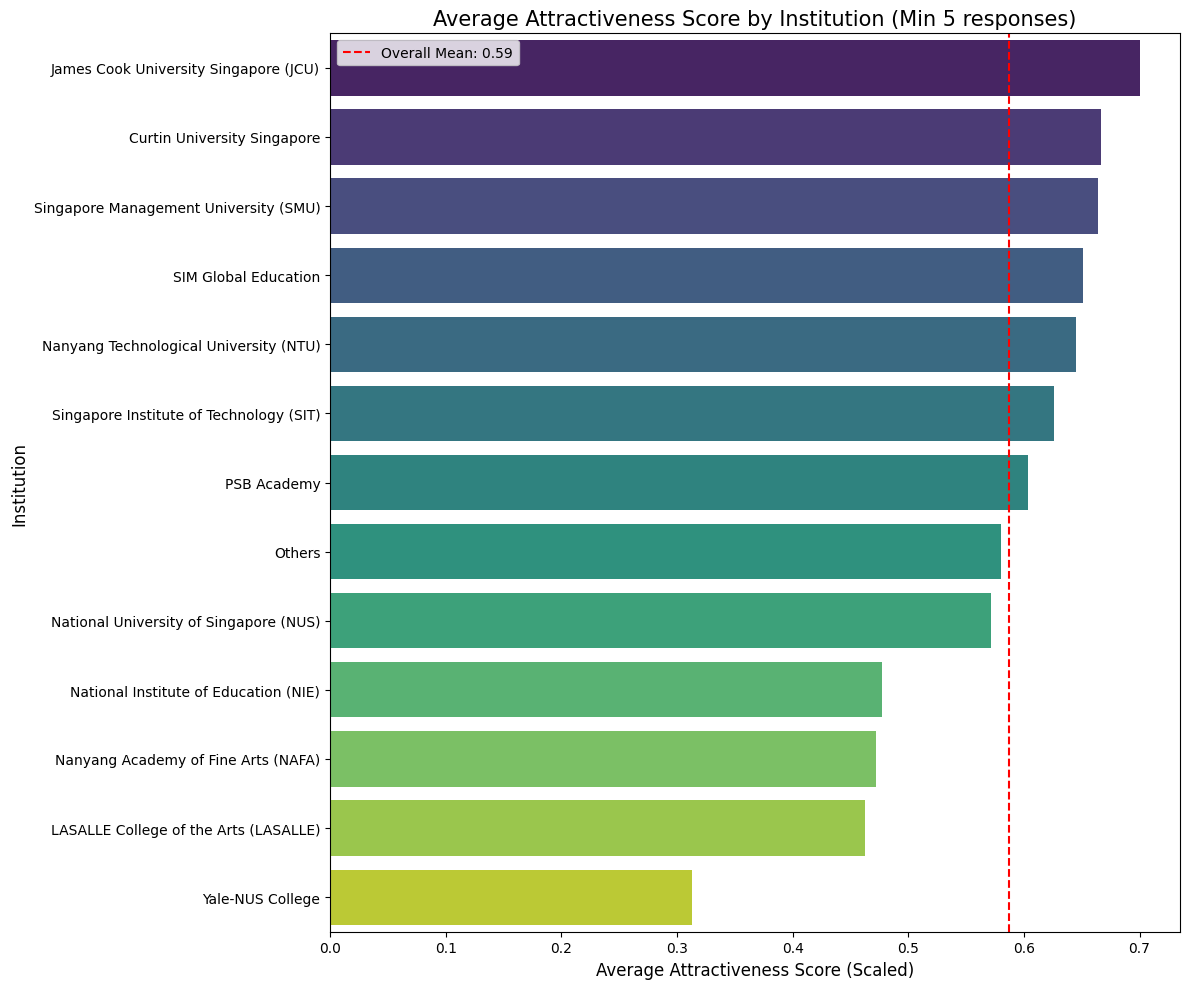

In [ ]:
# Analysis of Attractiveness by Institution
feature_inst = 'Which higher education institution do you or did you study at?'
min_responses_inst = 5

# Calculate mean, count, and std
inst_scores = analysis_df.groupby(feature_inst)[target_col].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False)

# Filter for relevance
filtered_inst_scores = inst_scores[inst_scores['count'] >= min_responses_inst]

# Plot 1: Horizontal Bar Chart of Means
plt.figure(figsize=(12, 10))
sns.barplot(x='mean', y=filtered_inst_scores.index, data=filtered_inst_scores.reset_index(), palette='viridis')
plt.axvline(analysis_df[target_col].mean(), color='red', linestyle='--',
            label=f'Overall Mean: {analysis_df[target_col].mean():.2f}')
plt.title(f'Average Attractiveness Score by Institution (Min {min_responses_inst} responses)', fontsize=15)
plt.xlabel('Average Attractiveness Score (Scaled)', fontsize=12)
plt.ylabel('Institution', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

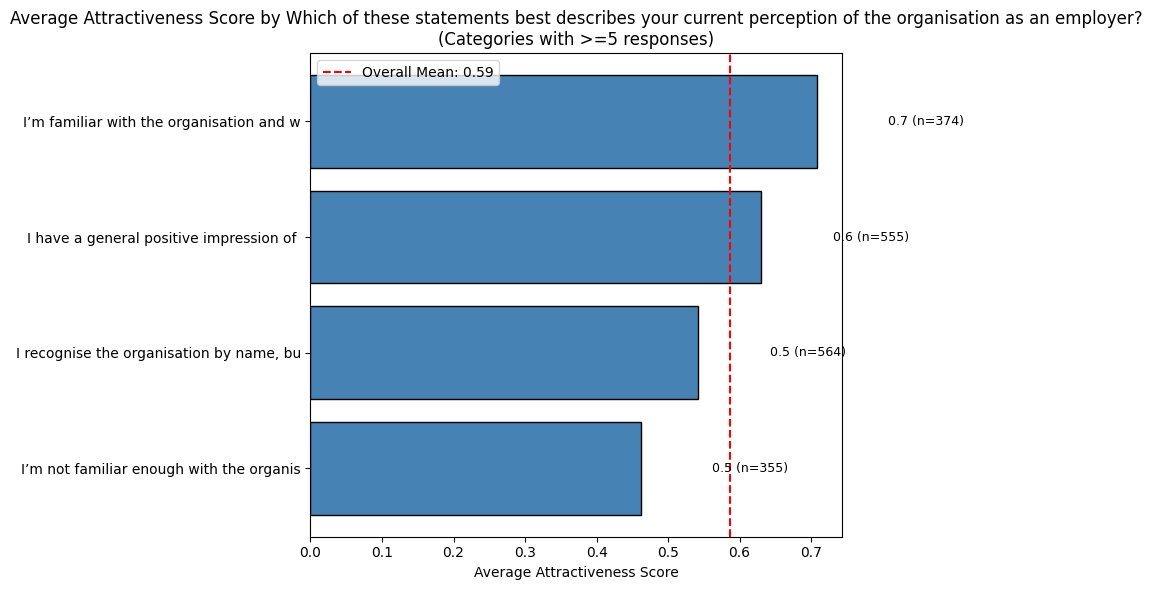

In [ ]:
feature = 'Which of these statements best describes your current perception of the organisation as an employer?'
top_n = 10

mean_scores = analysis_df.groupby(feature)['On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?'].agg(['mean', 'count'])
mean_scores = mean_scores[mean_scores['count'] >= 5]
mean_scores = mean_scores.sort_values('mean', ascending=True).tail(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(mean_scores)), mean_scores['mean'], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(mean_scores)))
ax.set_yticklabels([str(x)[:40] for x in mean_scores.index])
ax.set_xlabel('Average Attractiveness Score')
ax.set_title(f'Average Attractiveness Score by {feature}\n(Categories with >=5 responses)')
ax.axvline(analysis_df['On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?'].mean(), color='red', linestyle='--',
            label=f'Overall Mean: {analysis_df["On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?"].mean():.2f}')
ax.legend()

for i_idx, (val, count) in enumerate(zip(mean_scores['mean'], mean_scores['count'])):
    ax.text(val + 0.1, i_idx, f'{val:.1f} (n={count})', va='center', fontsize=9)

plt.tight_layout()
plt.show()